In [1]:
## load required packages
from dill.temp import b
import os
os.environ["JAX_PLATFORM_NAME"] = "cpu"

import jax
print("JAX path:", jax.__file__)

## load module
import sys

bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/illegal-dumping-nov12-2025/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/Elena/BSTPP')
#bstpp_module_dir = os.path.abspath('/Users/ctwomey/Research/WPF Illegal Dumping/project/BSTPP')
sys.path.insert(0, bstpp_module_dir)
import bstpp

import numpy as np
import numpyro
import numpyro.distributions as dist
import pandas as pd
import geopandas as gpd
from datetime import timedelta
import matplotlib.pyplot as plt
import seaborn as sns
#!pip install torch
import torch
from shapely.geometry import box
import contextily as ctx ## for basemap
from matplotlib_scalebar.scalebar import ScaleBar
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates 
import calendar
import matplotlib.ticker as ticker
from matplotlib.colors import ListedColormap
from shapely.geometry import Point ## for spatial jittering
import osmnx as ox
import shapely.geometry as geom
from scipy.stats import lomax
from collections import defaultdict
from statistics import mean, median
# from tqdm import tqdm
from tqdm.notebook import tqdm
from matplotlib.lines import Line2D
import matplotlib.dates as mdates
from datetime import datetime
import shapely


np.random.seed(999)


from bstpp.main import Hawkes_Model
from bstpp.trigger import Temporal_Power_Law, simulate_hawkes_like_events,plot_inter_arrival_distribution

from bstpp.cox_hawkes_shared import Cox_Hawkes_Shared, attach_litter_survey_args, attach_dumping_report_args, plot_dumping_report_regression
from bstpp.spatial_grid_helpers import get_grid_post_mean


JAX path: /Users/yuxin/miniconda3/lib/python3.12/site-packages/jax/__init__.py


In [2]:
## set working directory
import os
os.chdir("/Users/yuxin/Dropbox/DDDI/Illegal-Dumping")


## gdfs for plotting

In [3]:
## load land care data
land_care = gpd.read_file('data/Land_Care/phs_landcare.geojson')

land_care['year'] = pd.to_numeric(land_care['year'], errors='coerce')

## Filter for years between 2021 and 2025
land_care_21_25= land_care[(land_care['year'] >= 2021) & (land_care['year'] <= 2025)]

land_care_21_25 = land_care_21_25.to_crs(epsg=26918)

In [4]:
## load land use data
land_use_current = gpd.read_file('data/Land_Use/Land_use.geojson')

## recategorize land use types
land_use_current['type'] = pd.Series(dtype='object')

# residential
land_use_current.loc[(land_use_current['c_dig2'] == 11),'type'] = "Res Low Den"
land_use_current.loc[(land_use_current['c_dig2'] == 12),'type'] = "Res Med Den"
land_use_current.loc[(land_use_current['c_dig2'] == 13),'type'] = "Res High Den"
# commercial
land_use_current.loc[
    (land_use_current['c_dig2'] == 21) | (land_use_current['c_dig2'] == 22)|(land_use_current['c_dig2'] == 23),
    'type'
] = "Commercial"
# civic 
land_use_current.loc[
    (land_use_current['c_dig2'] == 41) | (land_use_current['c_dig2'] == 61)|(land_use_current['c_dig2'] == 62)|(land_use_current['c_dig2'] == 71)|(land_use_current['c_dig2'] == 72),
    'type'
] = "Civic"
# other
land_use_current.loc[(land_use_current['c_dig2'] == 31),'type'] = "Industry"
land_use_current.loc[(land_use_current['c_dig2'] == 51),'type'] = "Transportation"
land_use_current.loc[(land_use_current['c_dig2'] == 51),'type'] = "Green ROW"
land_use_current.loc[(land_use_current['c_dig2'] == 81),'type'] = "Water"
land_use_current.loc[(land_use_current['c_dig2'] == 91),'type'] = "Vacant"
land_use_current.loc[(land_use_current['c_dig2'] == 92),'type'] = "Other"

In [5]:
## Customize color map for land use categories
use_lst = ['Res Low Den', 'Res Med Den', 'Res High Den', 'Commercial', 'Civic', 'Industry', 'Transportation', 'Green ROW', 'Water', 'Vacant', 'Other']
colors = ['#543f32', '#db4d6d', '#69821b', '#e6b422', '#5654a2','#0095d9', '#a73836', '#a8bf93','#164a84', '#b3ada0','#d3cfd9']

use_color = dict(zip(colors,use_lst))

## reset order in land_use_currect
land_use_current['type'] = pd.Categorical(land_use_current['type'], categories=use_lst, ordered=True)

land_use_current = land_use_current.to_crs(epsg=26918)

In [6]:
## load data
vacant_block = gpd.read_file('data/Vacant_Block_Percent_Land.geojson')
vacant_block = vacant_block.to_crs(epsg=26918)

In [7]:
dumping_hotspot_gdf = gpd.read_file("data/PPR_BaseFiles_IllegalDumpingModel.gdb", 
                    layer='PPR_Dumping_HotSpots')
dumping_hotspot_gdf = dumping_hotspot_gdf.to_crs(epsg=26918) 

In [ ]:


focus_group_json_dir = "focus_group_map/JSON"
focus_group_files = [f for f in os.listdir(focus_group_json_dir) if f.endswith(".json")]
focus_group_data = {}

for file in focus_group_files:
    base = os.path.splitext(file)[0]
    var_name = "_".join(base.strip().lower().split())
    with open(os.path.join(focus_group_json_dir, file), "r") as jf:
        focus_group_data[var_name] = json.load(jf)


In [ ]:
# Convert all JSON files in focus_group_data from Esri JSON format to GeoJSON format with CRS 26918
from pyproj import Transformer
from shapely.geometry import Point

# Initialize transformer from Web Mercator (EPSG:3857) to EPSG:26918
transformer = Transformer.from_crs("EPSG:3857", "EPSG:26918", always_xy=True)

# Store GeoDataFrames for each converted file
focus_group_gdfs = {}

# Convert each JSON file in focus_group_data
for key, esri_data in focus_group_data.items():
    geometries = []
    properties_list = []
    
    # Convert each feature from Esri format
    for feature in esri_data.get("features", []):
        # Get coordinates (x, y in Web Mercator)
        x = feature["geometry"]["x"]
        y = feature["geometry"]["y"]
        
        # Transform directly to EPSG:26918
        x_26918, y_26918 = transformer.transform(x, y)
        
        # Create Point geometry with 26918 coordinates
        geometries.append(Point(x_26918, y_26918))
        
        # Get attributes
        properties_list.append(feature.get("attributes", {}))
    
    # Create GeoDataFrame with CRS 26918
    gdf = gpd.GeoDataFrame(properties_list, geometry=geometries, crs="EPSG:26918")
    focus_group_gdfs[key] = gdf
    
    # Save to GeoJSON file
    # output_path = f"output/{key}.geojson"
    # gdf.to_file(output_path, driver="GeoJSON")

In [10]:
focus_group_gdfs.keys()

dict_keys(['json_red', 'json_blue', 'json_white', 'json_yellow', 'json_green', 'json_clear'])

## Spliting Fairmount park

In [11]:
# load philly cbg border
pa_2023 = gpd.read_file(f"data/tiger/tl_2023_42_bg/tl_2023_42_bg.shp")
philly_2023 = pa_2023[pa_2023['COUNTYFP']=='101']
philly_2023 = philly_2023.to_crs(epsg=26918)

In [12]:
## load philly's city map for mapping
philly_border = gpd.read_file(f"data/City_Limits/City_Limits.shp")

philly_border = philly_border.to_crs(epsg=26918)

## load PPR data
ppr =gpd.read_file(f"parks/PPR/PPR_Properties.geojson")
ppr = ppr.to_crs(26918)

## get Cobbs Creek's map
cobbscreek = ppr[ppr["OBJECTID"].isin([432])]

## get Mifflin Square's map
mifflin = ppr[ppr["OBJECTID"].isin([208])]

## Tacony
tacony = ppr[ppr["OBJECTID"].isin([10, 64])]

## Fairmount: keep only west fairmount
fairmount = ppr[ppr["OBJECTID"].isin([7])]

### Load KML file 



In [13]:
# file is download from Google My Map on Feb 3rd, 2026.
# polygons are drawn
park_aoi = gpd.read_file("parks/park_AOI_from_google.kml", driver='KML')
park_aoi = park_aoi.to_crs(epsg=26918)
display(park_aoi.head())  # Preview the first few rows of the file

# extract fairmount_aoi and cobbs_aoi separately by 'Name' column
fairmount_aoi = park_aoi[park_aoi['Name'] == 'fairmount_AOI'].copy()
cobbs_aoi = park_aoi[park_aoi['Name'] == 'cobbs_AOI'].copy()
cobbs_aoi_focus = park_aoi[park_aoi['Name'] == 'cobbs_AOI_focus'].copy()

,Name,Description,geometry
0,fairmount_AOI,,"POLYGON Z ((481383.057 4427165.027 0, 480031.7..."
1,cobbs_AOI,,"POLYGON Z ((480178.438 4420734.662 0, 480545.9..."
2,cobbs_AOI_focus,,"POLYGON Z ((479122.352 4421669.753 0, 480248.3..."


In [14]:
# ## list of parks
# parks = {
#     'cobbscreek': cobbscreek,
#     'mifflin': mifflin,
#     'tacony': tacony,
#     'fairmount': fairmount,
# }
# aoi_parks = {
#     'fairmount_aoi': fairmount_aoi,
#     'cobbs_aoi': cobbs_aoi,
# }

# # set buffer value
# buffer = 300 # meters

# # collect results
# all_parks_gdf = gpd.GeoDataFrame(columns=['PARKNAME', 'geometry']) # for plotting, final columns only
# all_boxes_gdf = gpd.GeoDataFrame(columns=['PARKNAME', 'geometry']) # for filtering, final columns only

# # handle "standard" parks (with usual columns)
# for name, gdf in parks.items():
#     if gdf.empty:
#         continue

#     # append to all_parks_gdf: keep only PARKNAME and geometry
#     # if PARKNAME not present, use name
#     tmp_gdf = gdf.copy()
#     if 'PARKNAME' not in tmp_gdf.columns:
#         tmp_gdf['PARKNAME'] = name
#     tmp_gdf = tmp_gdf[['PARKNAME', 'geometry']]
#     all_parks_gdf = pd.concat([all_parks_gdf, tmp_gdf], ignore_index=True)

#     # compute total bounds for buffered box
#     minx, miny, maxx, maxy = gdf.total_bounds
#     minx -= buffer
#     maxx += buffer
#     miny -= buffer
#     maxy += buffer

#     # compute the side length of the square
#     side = max(maxx - minx, maxy - miny)
#     center_x = (minx + maxx) / 2
#     center_y = (miny + maxy) / 2

#     # create square box
#     square_minx = center_x - side / 2
#     square_maxx = center_x + side / 2
#     square_miny = center_y - side / 2
#     square_maxy = center_y + side / 2
#     square_geom = box(square_minx, square_miny, square_maxx, square_maxy)

#     # create GeoDataFrame for box, with only PARKNAME and geometry
#     square_gdf = gpd.GeoDataFrame(
#         {'PARKNAME': [f"{name}_box"]},
#         geometry=[square_geom],
#         crs=gdf.crs
#     )
#     all_boxes_gdf = pd.concat([all_boxes_gdf, square_gdf[['PARKNAME', 'geometry']]], ignore_index=True)

# # now append AOI parks (geometry is POLYGON Z, columns are ['Name', ... 'geometry'])
# for name, gdf in aoi_parks.items():
#     if gdf.empty:
#         continue
#     # Make sure geometry is present
#     tmp_gdf = gdf.copy()
#     # 'Name' is the "PARKNAME"
#     tmp_gdf = tmp_gdf.rename(columns={'Name': 'PARKNAME'})
#     tmp_gdf = tmp_gdf[['PARKNAME', 'geometry']]
#     all_parks_gdf = pd.concat([all_parks_gdf, tmp_gdf], ignore_index=True)

#     # box for AOI: use total bounds like others, but AOIs might not have a CRS set (likely EPSG:4326)
#     if tmp_gdf.crs is None:
#         # reproject to 26918 so buffer math is in meters
#         tmp_gdf = tmp_gdf.set_crs(4326).to_crs(26918)
#     minx, miny, maxx, maxy = tmp_gdf.total_bounds
#     minx -= buffer
#     maxx += buffer
#     miny -= buffer
#     maxy += buffer
#     side = max(maxx - minx, maxy - miny)
#     center_x = (minx + maxx) / 2
#     center_y = (miny + maxy) / 2
#     square_minx = center_x - side / 2
#     square_maxx = center_x + side / 2
#     square_miny = center_y - side / 2
#     square_maxy = center_y + side / 2
#     square_geom = box(square_minx, square_miny, square_maxx, square_maxy)

#     box_gdf = gpd.GeoDataFrame(
#         {'PARKNAME': [f"{name}_box"]},
#         geometry=[square_geom],
#         crs=tmp_gdf.crs
#     )
#     all_boxes_gdf = pd.concat([all_boxes_gdf, box_gdf[['PARKNAME','geometry']]], ignore_index=True)

In [15]:
def create_parks_and_boxes(parks, max_area_sq_meters=2500000):
    """
    Create parks and bounding boxes GeoDataFrames from input parks dictionary.
    
    Parameters:
    -----------
    parks : dict
        Dictionary with keys as park names and values as GeoDataFrames.
        GeoDataFrames can have either:
        - Standard format: may have 'PARKNAME' column, or will use dict key
        - AOI format: must have 'Name' column (will be renamed to 'PARKNAME')
    
    max_area_sq_meters : float, default=2500000
        Maximum area for each bounding box in square meters.
        The function will calculate a dynamic buffer to maximize coverage
        while staying under this limit.
    
    Returns:
    --------
    all_parks_gdf : GeoDataFrame
        GeoDataFrame with columns ['PARKNAME', 'geometry'] containing all park geometries.
    
    all_boxes_gdf : GeoDataFrame
        GeoDataFrame with columns ['PARKNAME', 'geometry'] containing square (or original)
        bounding geometries for each park, with area <= max_area_sq_meters where applicable.
    """
    
    # Maximum side length for square box (area = side^2)
    max_side = np.sqrt(max_area_sq_meters)
    
    # Collect results
    all_parks_gdf = gpd.GeoDataFrame(columns=['PARKNAME', 'geometry'])
    all_boxes_gdf = gpd.GeoDataFrame(columns=['PARKNAME', 'geometry'])
    
    for name, gdf in parks.items():
        if gdf.empty:
            continue
        
        # Prepare park geometry for all_parks_gdf
        tmp_gdf = gdf.copy()
        
        # Handle CRS: ensure we're in a projected CRS (26918) for area calculations
        if tmp_gdf.crs is None:
            tmp_gdf = tmp_gdf.set_crs(4326).to_crs(26918)
        elif tmp_gdf.crs != 26918:
            tmp_gdf = tmp_gdf.to_crs(26918)
        
        # Handle PARKNAME column
        if 'PARKNAME' not in tmp_gdf.columns:
            if 'Name' in tmp_gdf.columns:
                tmp_gdf = tmp_gdf.rename(columns={'Name': 'PARKNAME'})
            else:
                tmp_gdf['PARKNAME'] = name
        
        # Add to all_parks_gdf
        tmp_gdf = tmp_gdf[['PARKNAME', 'geometry']]
        all_parks_gdf = pd.concat([all_parks_gdf, tmp_gdf], ignore_index=True)

        # Special case: for 'cobbs_aoi_focus', do NOT create an expanded box.
        # Instead, keep the original polygon as its "box" geometry and skip
        # the dynamic square buffer. Also, drop any Z coordinates so the
        # geometry is a 2D Polygon (not Polygon Z).
        if name == 'cobbs_aoi_focus':
            focus_box_gdf = tmp_gdf.copy()
            # Force geometries to 2D in case they are Polygon Z
            focus_box_gdf['geometry'] = focus_box_gdf['geometry'].apply(
                lambda geom: shapely.force_2d(geom) if geom is not None else geom
            )
            # Use the dict key as PARKNAME so you can select with 'cobbs_aoi_focus'
            focus_box_gdf['PARKNAME'] = name
            all_boxes_gdf = pd.concat(
                [all_boxes_gdf, focus_box_gdf[['PARKNAME', 'geometry']]],
                ignore_index=True,
            )
            continue
        
        # Calculate bounding box with dynamic buffer
        minx, miny, maxx, maxy = tmp_gdf.total_bounds
        width = maxx - minx
        height = maxy - miny
        
        # Minimum side needed to cover the polygon
        min_side = max(width, height)
        
        # Use maximum allowed side to maximize coverage
        # If min_side > max_side, we can't fully cover, so use max_side (maximum allowed)
        # Otherwise, use max_side to maximize coverage beyond the minimum needed
        side = max_side if min_side <= max_side else min(max_side, min_side)
        
        # Calculate center of original bounds
        center_x = (minx + maxx) / 2
        center_y = (miny + maxy) / 2
        
        # Create square box centered on the polygon
        square_minx = center_x - side / 2
        square_maxx = center_x + side / 2
        square_miny = center_y - side / 2
        square_maxy = center_y + side / 2
        square_geom = box(square_minx, square_miny, square_maxx, square_maxy)
        
        # Create GeoDataFrame for box
        square_gdf = gpd.GeoDataFrame(
            {'PARKNAME': [f"{name}_box"]},
            geometry=[square_geom],
            crs=tmp_gdf.crs
        )
        all_boxes_gdf = pd.concat([all_boxes_gdf, square_gdf[['PARKNAME', 'geometry']]], ignore_index=True)
    
    return all_parks_gdf, all_boxes_gdf


In [16]:

## Input parks dictionary
parks = {
    'cobbscreek': cobbscreek,
    'mifflin': mifflin,
    'tacony': tacony,
    'fairmount': fairmount,
    'fairmount_aoi': fairmount_aoi,
    'cobbs_aoi': cobbs_aoi,
    'cobbs_aoi_focus': cobbs_aoi_focus
}
## Create parks and boxes with dynamic buffer (max area = 2,500,000 sq meters)
all_parks_gdf, all_boxes_gdf = create_parks_and_boxes(parks, max_area_sq_meters=3000000)

In [17]:
# Calculate area of tacony_box and fairmount_box and print it

# Get the geometries for tacony_box and fairmount_box
fairmount_aoi_box = all_boxes_gdf.loc[all_boxes_gdf['PARKNAME'] == 'tacony_box', 'geometry']
fairmount_box_geom = all_boxes_gdf.loc[all_boxes_gdf['PARKNAME'] == 'fairmount_box', 'geometry']

# Calculate their areas (in the units of the CRS, which should be meters^2 for projected CRS)
fairmount_aoi_box = fairmount_aoi_box.area.values[0] if not fairmount_aoi_box.empty else None
fairmount_box_area = fairmount_box_geom.area.values[0] if not fairmount_box_geom.empty else None

print(f"Area of tacony_box: {fairmount_aoi_box} square meters")
print(f"Area of fairmount_aoi_box: {fairmount_box_area} square meters")


Area of tacony_box: 3000000.00000043 square meters
Area of fairmount_aoi_box: 3000000.00000043 square meters


In [18]:
print(f"Area of fairmount_aoi: {fairmount_aoi.area.values[0]} square meters")

Area of fairmount_aoi: 1488732.9978156863 square meters


In [19]:
## load covariates
cov_gdf = gpd.read_file(f"output/cov_cbg.geojson")
cov_gdf = cov_gdf.to_crs(epsg=26918)

In [20]:
## loadding filtered 311 data
illegal_dumping = gpd.read_file(f"output/illegal_dumping_full.geojson")

## filter out cases after 2024-12-31
illegal_dumping = illegal_dumping[illegal_dumping['start_time'] <= '2025-01-01']

## set total days
total_days = 365 * 4

print(illegal_dumping.shape[0])

109815


In [21]:
# Divide fairmount_box into 2x2 grid, get the bottom-left (southwest) quarter, and store it as a new row in all_boxes_gdf

# Extract fairmount_box geometry
fairmount_geom = all_boxes_gdf.loc[all_boxes_gdf['PARKNAME'] == 'fairmount_box', 'geometry'].values[0]

# Get bounds
minx, miny, maxx, maxy = fairmount_geom.bounds
mid_x = (minx + maxx) / 2
mid_y = (miny + maxy) / 2

# Bottom-left quarter (SW corner)
left_bottom_box = shapely.geometry.box(minx, miny, mid_x, mid_y)

# Store the new quarter as a new row in all_boxes_gdf
new_row = gpd.GeoDataFrame(
    {'PARKNAME': ['fairmount_box_left_bottom']},
    geometry=[left_bottom_box],
    crs=all_boxes_gdf.crs
)
all_boxes_gdf = pd.concat([all_boxes_gdf, new_row], ignore_index=True)



In [46]:
# First join: illegal dumping within all_boxes_gdf
illegal_dumping_in_park = illegal_dumping.sjoin(all_boxes_gdf, predicate='within')
illegal_dumping_in_park = illegal_dumping_in_park.drop(columns=['index_right'])

# Second join: filter to only keep points that are also in cov_cbg
illegal_dumping_in_park = illegal_dumping_in_park.sjoin(
    cov_gdf, 
    predicate='within', 
    how='inner'  # Only keep points that match both conditions
)

# set park name
park_name = "fairmount_aoi_box"

park_points = illegal_dumping_in_park[illegal_dumping_in_park['PARKNAME'] == park_name].reset_index(drop=True)
park_points = park_points.loc[:, park_points.columns != 'index_right']
park_points.shape

(550, 66)

In [23]:
park_points.head()

,start_time,close_time,request_id,type,department,address,zipcode,status,problem_category,problem,...,landcare_area,area_B,alloc_avg_d_cnt,alloc_avg_s_cnt,unique_device_ratio_aw,reporting_rate,betweenness_avg_w,pagerank_avg_w,betweenness_avg_d,pagerank_avg_d
0,2021-06-30 12:56:00,2021-08-31 07:36:00,14244796,Illegal Dumping,Streets Department,CHRISTIAN ST & S 56TH ST,None,Closed,None,None,...,158.044215,147971.333133,1042.750000,2973.562500,0.361163,0.010251,0.001155,0.000009,0.000014,0.000039
1,2021-05-02 03:12:00,2021-05-08 12:17:00,14108929,Illegal Dumping,Streets Department,5663 PENTRIDGE ST,19143.0,Closed,None,None,...,293.515678,80018.755110,253.229167,777.562500,0.330000,0.027969,0.001084,0.000009,0.000013,0.000043
2,2021-05-27 16:54:00,2021-06-01 13:18:00,14167442,Illegal Dumping,Streets Department,ANGORA TER & COBBS CREEK PKWY,None,Closed,None,None,...,322.887044,148241.659057,1385.479167,3154.104167,0.440000,0.004900,0.001784,0.000009,0.000016,0.000044
3,2021-01-28 08:10:00,2021-02-03 08:33:00,13902696,Illegal Dumping,Streets Department,5555 WHITBY AVE,19143.0,Closed,None,None,...,0.000000,52606.433591,202.000000,975.062500,0.210000,0.010123,0.000736,0.000009,0.000017,0.000051
4,2021-03-08 22:25:00,2021-03-22 13:18:00,13988586,Illegal Dumping,Streets Department,5407 ANGORA TER,19143.0,Closed,None,None,...,0.000000,113309.499788,495.450718,1494.137288,0.330606,0.008094,0.001985,0.000009,0.000037,0.000039


<Axes: >

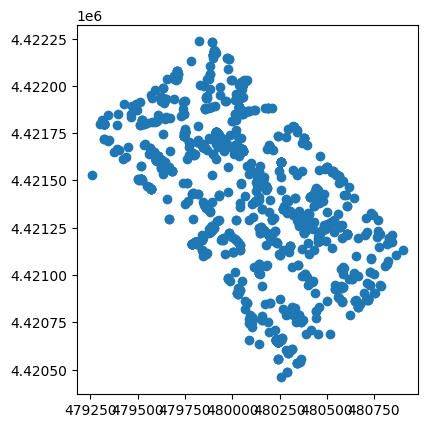

In [24]:
park_points.plot()

In [25]:
# get coordinates from the geometry
coords = pd.DataFrame({
    'x': park_points.geometry.centroid.x,
    'y': park_points.geometry.centroid.y
})

# calculate time difference in days from the minimum date
offset_seasonal = 30 * 0
min_year        = pd.to_datetime(park_points['start_time'].min())
min_time        = pd.Timestamp(f"{min_year.year}-01-01")
time            = (park_points['start_time'] - min_time).dt.total_seconds() / (24 * 60 * 60)
seasonal        = (time + offset_seasonal) % 365
park_points['time_diff']     = time
park_points['seasonal_diff'] = seasonal

# Create locs_s DataFrame
locs_s = pd.DataFrame({
    'X': coords['x'].astype(float),
    'Y': coords['y'].astype(float),
    'T': time.astype(float),
    'A': seasonal.astype(float)
})

In [26]:
## Cox-Hawkes model

# a_0 = baseline log-intensity
# alpha = magnitute of excitation
# bate = temporal decay rate
# sigmax_2 = spatial decay scale
column_names = ['pop_density', 'med_inc_avg','lep_density','edu_hs_avg','ndvi_mean_4yr'
                ,'RLD', 'RMD','RHD','use_com', 'use_civ','I', 'T', 'GW',
                'vac_area','landcare_area',
                'alloc_avg_d_cnt','alloc_avg_s_cnt','unique_device_ratio_aw','reporting_rate',
                'betweenness_avg_w', 'pagerank_avg_w', 'betweenness_avg_d','pagerank_avg_d']

model = bstpp.main.Hawkes_Model(
    locs_s,     # spatiotemporal points
    #univ_square_gdf,
    all_boxes_gdf[all_boxes_gdf['PARKNAME']==park_name], # philly boundaries
    total_days, # Time frame
    True,       # use Cox as background
    spatial_cov = cov_gdf,#spatial covariate matrix
    cov_names = column_names,#columns to use from covariates
    standardize_cov = True,
    a_0      = dist.Normal(0,2),
    alpha    = dist.Beta(2,2),
    #beta     = dist.HalfNormal(1.0),
    beta     = dist.Exponential(1.0),
    gamma    = dist.Exponential(1.0),
    sigmax_2 = dist.HalfNormal(0.25),
    offset_seasonal = offset_seasonal,
    temporal_trig = bstpp.trigger.Temporal_Power_Law
)

[DEBUG] set_window called with:
  window type: <class 'float'> value: 100.0
  spatial_window type: <class 'float'> value: 0.1
[DEBUG] aligned_difference_pairs called with:
  t type: <class 'numpy.ndarray'> dtype: float64 shape: (1260,)
  x type: <class 'numpy.ndarray'> dtype: float64 shape: (1260,)
  y type: <class 'numpy.ndarray'> dtype: float64 shape: (1260,)
  window type: <class 'float'> value: 100.0
  spatial_window type: <class 'float'> value: 0.1
[set_window] Temporal window set to: 100.0
[set_window] Number of events: 1260
[set_window] Number of pairs: 65711
[set_window] Max t_diff in pairs: 49.318255327245055
[set_window] Min t_diff in pairs: 2.3782343985701004e-05
[set_window] All t_diff <= window: True
[set_window] All t_diff > 0: True
[set_window] Spatial window set to: 0.1
[set_window] Max spatial distance: 0.09999596327543259
[set_window] Min spatial distance: 0.0
[set_window] All spatial distances <= window: True


100%|██████████| 10000/10000 [00:16<00:00, 600.87it/s, init loss: 116580.8750, avg. loss [9501-10000]: -34385.4922]


Number of posterior samples: 1000
Number of pairs: 65711
coords shape: (65711, 2)

SVI elapsed time: 23.87039804458618


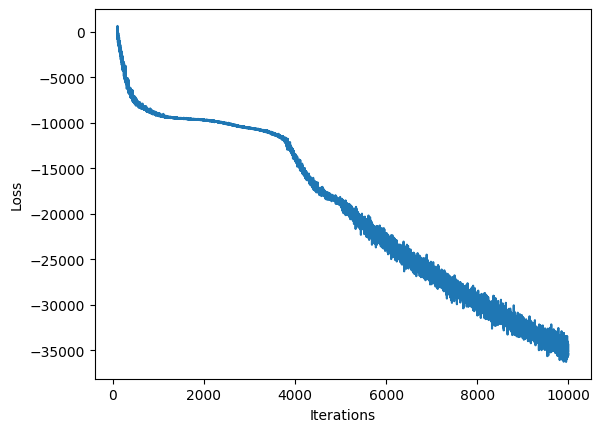

In [27]:
model.set_window(window = 100, spatial_window= 0.1)
## 100

# less interations and bigger learning rate
model.run_svi(lr=0.01,num_steps=10000)


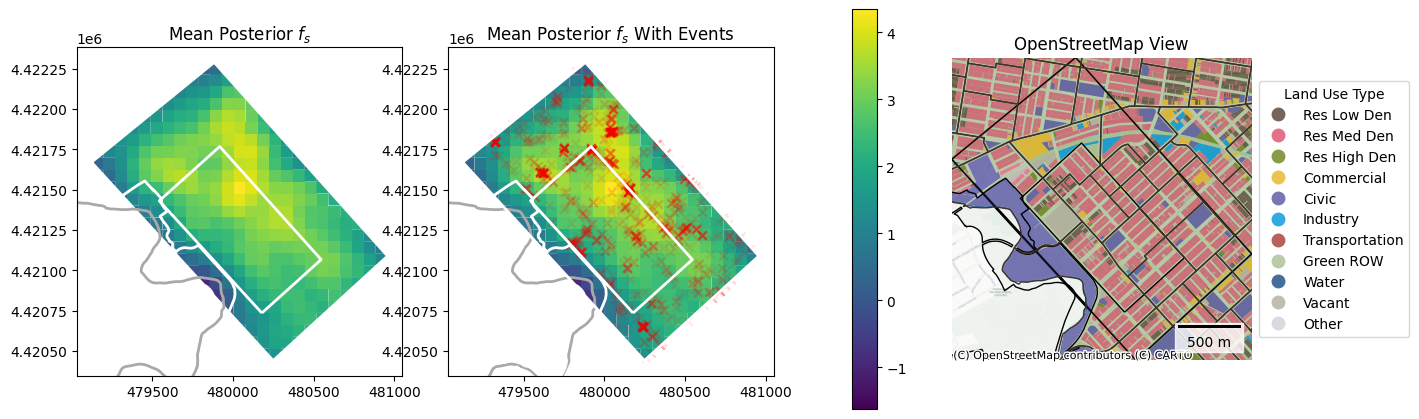

In [28]:
## Spatial trigger ------------------------------------------------------
# Step 1: Draw the original plot
model.plot_spatial(include_cov=False)

# Step 2: Grab the existing figure and axes
fig = plt.gcf()
axs = fig.get_axes()  # Usually [ax0, ax1, colorbar_ax]

# Match limits from left subplot
xlim = axs[0].get_xlim()
ylim = axs[0].get_ylim()

#philly_border.plot(ax=axs[0], edgecolor='red', facecolor='none', linewidth=2)
all_parks_gdf.plot(ax=axs[0], edgecolor='white', facecolor='none', linewidth=2)
philly_border.plot(ax=axs[0], edgecolor='darkgray', facecolor='none', linewidth=2)

axs[0].set_xlim(xlim)
axs[0].set_ylim(ylim)

# Add overlays
#all_boxes_gdf.plot(ax=axs[1], edgecolor='blue', facecolor='none', linewidth=2)
philly_border.plot(ax=axs[1], edgecolor='darkgray', facecolor='none', linewidth=2)
all_parks_gdf.plot(ax=axs[1], edgecolor='white', facecolor='none', linewidth=2)


# Set the same limits on the right subplot
axs[1].set_xlim(xlim)
axs[1].set_ylim(ylim)

# Step 3: Add a new axis to the right
osm_ax = fig.add_axes([1, 0.1, 0.3, 0.8])  # [left, bottom, width, height]

# Step 4: Draw the OpenStreetMap on the new axis
osm_box = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name].to_crs(epsg=3857)
philly_2023_3857 = philly_2023.to_crs(epsg=3857)
all_parks_3857 = all_parks_gdf.to_crs(epsg=3857)
land_use_current = land_use_current.to_crs(epsg=3857)
land_care_21_25 = land_care_21_25.to_crs(epsg=3857)
vacant_block = vacant_block.to_crs(epsg = 3857)

# plot cbg and park boundary
philly_2023_3857.plot(ax=osm_ax, edgecolor='#3f312b', facecolor='none', linewidth=1, zorder=3)
all_parks_3857.plot(ax=osm_ax, color='none', edgecolor='black', linewidth=1, zorder=2)
osm_box.plot(ax=osm_ax, edgecolor='black', facecolor='none', linewidth=2, zorder=1)
#land_care_21_25.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='#00ffff', alpha=0.7,linewidth=1,zorder=4)
#vacant_block.plot(ax=osm_ax, edgecolor='#ff00ff', facecolor='gray', alpha=0.7,linewidth=1, zorder=4)

## plot land use type
land_use_current['type'] = land_use_current['type'].astype('category')
#cmap = 'tab20b' # set qualitatitive color map
cmap = ListedColormap(use_color)

land_use_current[land_use_current['year'] == 2023].plot(
    ax=osm_ax,
    column='type',
    cmap=cmap,
    alpha=0.8,
    legend=True,
    legend_kwds={
        'loc': 'center left',
        'bbox_to_anchor': (1, 0.5),
        'title': 'Land Use Type'
    }
)

# Zoom to Cobbs Creek Park
xlim = osm_box.total_bounds[[0, 2]]
ylim = osm_box.total_bounds[[1, 3]]
osm_ax.set_xlim(xlim)
osm_ax.set_ylim(ylim)

ctx.add_basemap(osm_ax, source=ctx.providers.CartoDB.Positron)
#ctx.add_basemap(osm_ax)


# Add the scale bar in kilometers
scalebar = ScaleBar(
    dx=1,  # 1 pixel = 1 meter (Web Mercator)
    units='m',  # use kilometers
    dimension='si-length',
    length_fraction=0.25,
    location='lower right',
    scale_loc='bottom',
    box_color='white',
    box_alpha=0.8,
    border_pad=0.6,
    color='black',
    font_properties={'size': 10}
)
osm_ax.add_artist(scalebar)

# Optional: Clean up
osm_ax.set_title("OpenStreetMap View")
osm_ax.set_axis_off()

#plt.savefig('output/spatial_trigger_mifflin_zoning_full.png', dpi=500, bbox_inches='tight')


Grid size: 25x25


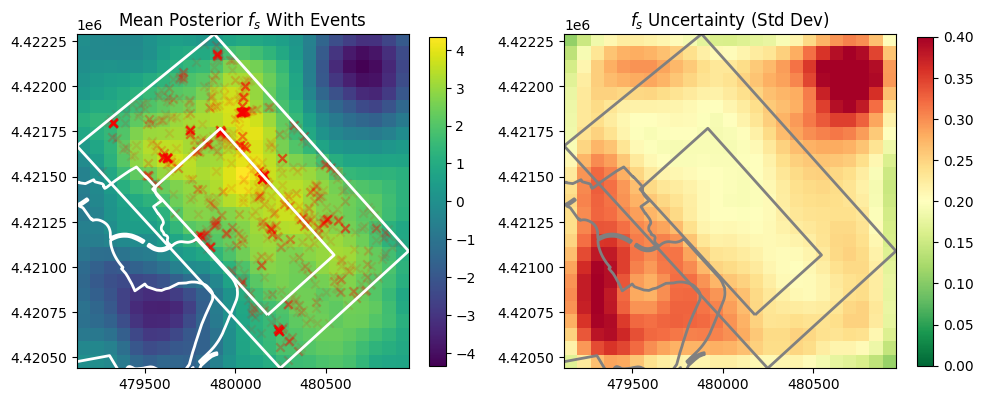

Mean f_xy range: -4.342 to 4.350
Std f_xy range: 0.109 to 0.470


In [ ]:
## Uncertainty map ------------------------------------------------------
# Get uncertainty measures
f_xy_samples = model.samples["f_xy"]
f_xy_mean = np.mean(f_xy_samples, axis=0)
f_xy_std = np.std(f_xy_samples, axis=0) # Standard deviation across samples

# Get boundary from model.A geometry
bounds = model.A[['geometry']].total_bounds  # [minx, miny, maxx, maxy]
minx, miny, maxx, maxy = bounds

# Since spatial_grid contains indices, we need to create coordinates
# For a 625-cell grid, this is likely a 25x25 grid (25² = 625)
grid_size = int(np.sqrt(625))  # Should be 25
print(f"Grid size: {grid_size}x{grid_size}")

# Create coordinate arrays based on actual geometry bounds
x_indices = np.linspace(minx, maxx, grid_size)
y_indices = np.linspace(miny, maxy, grid_size)
X, Y = np.meshgrid(x_indices, y_indices)

# Reshape data to match the grid
f_xy_mean_grid = f_xy_mean.reshape(grid_size, grid_size)
f_xy_std_grid = f_xy_std.reshape(grid_size, grid_size)

# Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# Mean surface
im1 = ax1.imshow(f_xy_mean_grid, origin='lower', cmap='viridis', extent=[minx, maxx, miny, maxy])
model.points.plot(ax=ax1,color='red',marker='x',alpha=0.1)
all_parks_gdf.plot(ax=ax1, edgecolor='white', facecolor='none', linewidth=2)

ax1.set_title('Mean Posterior $f_s$ With Events')
ax1.set_xlim(minx, maxx)  # Set x limits to bounds
ax1.set_ylim(miny, maxy)  # Set y limits to bounds
plt.colorbar(im1, ax=ax1, shrink=0.7)

# Uncertainty surface
im2 = ax2.imshow(f_xy_std_grid, origin='lower', cmap='RdYlGn_r', extent=[minx, maxx, miny, maxy], vmin=0, vmax=0.4)
all_parks_gdf.plot(ax=ax2, edgecolor='gray', facecolor='none', linewidth=2)

ax2.set_title('$f_s$ Uncertainty (Std Dev)')
ax2.set_xlim(minx, maxx)  # Set x limits to bounds
ax2.set_ylim(miny, maxy)  # Set y limits to bounds
plt.colorbar(im2, ax=ax2, shrink=0.7)

plt.tight_layout()
# plt.savefig('output/uncertainty_mifflin.png', dpi=500, bbox_inches='tight')
plt.show()

# Print some summary statistics
print(f"Mean f_xy range: {f_xy_mean.min():.3f} to {f_xy_mean.max():.3f}")
print(f"Std f_xy range: {f_xy_std.min():.3f} to {f_xy_std.max():.3f}")

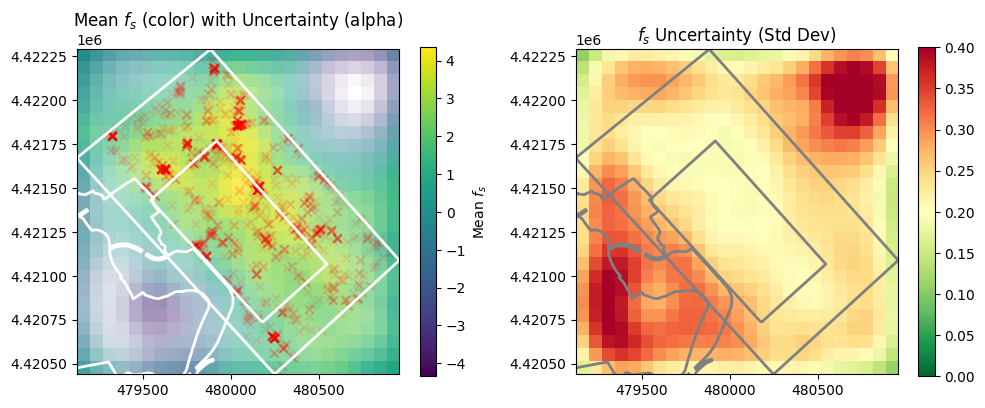

Mean f_xy range: -4.342 to 4.350
Std f_xy range: 0.109 to 0.470


In [45]:
## Uncertainty map with mean-colored, std-weighted alpha on ax1

# Get uncertainty measures
f_xy_samples = model.samples["f_xy"]
f_xy_mean = np.mean(f_xy_samples, axis=0)
f_xy_std = np.std(f_xy_samples, axis=0)  # Standard deviation across samples

# Get boundary from model.A geometry
bounds = model.A[["geometry"]].total_bounds  # [minx, miny, maxx, maxy]
minx, miny, maxx, maxy = bounds

# For a 625-cell grid, this is a 25x25 grid (25² = 625)
grid_size = int(np.sqrt(625))  # 25

# Coordinate arrays based on actual geometry bounds
x_indices = np.linspace(minx, maxx, grid_size)
y_indices = np.linspace(miny, maxy, grid_size)
X, Y = np.meshgrid(x_indices, y_indices)

# Reshape data to match the grid
f_xy_mean_grid = f_xy_mean.reshape(grid_size, grid_size)
f_xy_std_grid = f_xy_std.reshape(grid_size, grid_size)

# Create the plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

# --- ax1: mean as color, std as alpha ---
from matplotlib import colors as mcolors

# Normalize mean for colormap
cmap = plt.get_cmap("viridis")
norm_mean = mcolors.Normalize(vmin=f_xy_mean.min(), vmax=f_xy_mean.max())
rgba = cmap(norm_mean(f_xy_mean_grid))  # shape (25, 25, 4)

# Normalize std to [0, 1] and invert so higher uncertainty → more transparent
std_min, std_max = f_xy_std_grid.min(), f_xy_std_grid.max()
std_norm = (f_xy_std_grid - std_min) / (std_max - std_min + 1e-9)
alpha_grid = 1.0 - std_norm  # high std → low alpha

# Apply alpha to RGBA array
rgba[..., -1] = alpha_grid

# Show RGBA image
im1 = ax1.imshow(rgba, origin="lower", extent=[minx, maxx, miny, maxy])
model.points.plot(ax=ax1, color="red", marker="x", alpha=0.1)
all_parks_gdf.plot(ax=ax1, edgecolor="white", facecolor="none", linewidth=2)

ax1.set_title("Mean $f_s$ (color) with Uncertainty (alpha)")
ax1.set_xlim(minx, maxx)
ax1.set_ylim(miny, maxy)

# Add colorbar for the mean values (use the same colormap and norm)
cb1 = plt.colorbar(
    mappable=plt.cm.ScalarMappable(norm=norm_mean, cmap=cmap),
    ax=ax1,
    shrink=0.7
)
cb1.set_label("Mean $f_s$")

# --- ax2: keep the same std-dev map as before ---
im2 = ax2.imshow(
    f_xy_std_grid,
    origin="lower",
    cmap="RdYlGn_r",
    extent=[minx, maxx, miny, maxy],
    vmin=0,
    vmax=0.4,
)
all_parks_gdf.plot(ax=ax2, edgecolor="gray", facecolor="none", linewidth=2)

ax2.set_title("$f_s$ Uncertainty (Std Dev)")
ax2.set_xlim(minx, maxx)
ax2.set_ylim(miny, maxy)
plt.colorbar(im2, ax=ax2, shrink=0.7)

plt.tight_layout()
plt.show()

# Print some summary statistics
print(f"Mean f_xy range: {f_xy_mean.min():.3f} to {f_xy_mean.max():.3f}")
print(f"Std f_xy range: {f_xy_std.min():.3f} to {f_xy_std.max():.3f}")


In [30]:
def get_box_polygon_from_diag_vertices(parkname, v1, v2):
    """
    Given a parkname, select a rectangular box from all_boxes_gdf,
    and return a GeoDataFrame containing a shapely Polygon defined by two diagonal vertices (grid coords, e.g. (x1, y1), (x2, y2)).
    v1: (x1, y1) -- one vertex (typically top-left)
    v2: (x2, y2) -- opposite vertex (typically bottom-right)
    All coords should be in the inclusive range 0..24.
    """
    # Access all_boxes_gdf in the outer scope
    box_row = all_boxes_gdf[all_boxes_gdf['PARKNAME'] == parkname]
    if box_row.empty:
        raise ValueError(f"No box polygon found for parkname: {parkname}")
    box_geom = box_row.iloc[0].geometry

    # Obtain box polygon bounds
    minx, miny, maxx, maxy = box_geom.bounds
    # From grid coords (0..24), make linspaces (use grid size)
    grid_n = 24  # x and y ranges from 0 to 24 inclusive → 25 x/y positions
    xs = np.linspace(minx, maxx, grid_n+1)
    ys = np.linspace(miny, maxy, grid_n+1)

    # Interpret (x, y) grid coordinates so x is counted from the left (minx) and y is counted from the top (maxy)
    # For v1 = (5,5), this means the 5th from the left and 5th from the top
    x1, y1 = v1
    x2, y2 = v2

    grid_n = 24  # total grid is 25x25
    # For x: left is index 0, right is index 24 (no change)
    # For y: top is index 0, so to get 5th from the top, index is 5
    # However, to map 'from top' to 'from bottom', we need to flip the y axis:
    def ytop_to_index(y):
        return y

    # Enforce: x means index from left, y means index from top (so y==0 is top row, y==24 is bottom row)
    x_lo, x_hi = sorted([x1, x2])
    y_lo, y_hi = sorted([y1, y2])

    # To convert 'from top' to the corresponding y index in spatial coordinates,
    # since ys[0] is miny (bottom), ys[24] is maxy (top), so we flip
    def y_from_top(y):  # y = 0 means top (maxy), so map y=0->24, y=1->23, ...
        return grid_n - y

    y_lo_idx = y_from_top(y_lo)
    y_hi_idx = y_from_top(y_hi)

    # Convert grid coords to spatial coordinates
    poly_coords = [
        (xs[x_lo], ys[y_lo_idx]),     # bottom-left (low x, low y)
        (xs[x_lo], ys[y_hi_idx]),     # top-left   (low x, high y)
        (xs[x_hi], ys[y_hi_idx]),     # top-right  (high x, high y)
        (xs[x_hi], ys[y_lo_idx]),     # bottom-right(high x, low y)
        (xs[x_lo], ys[y_lo_idx]),     # close polygon
    ]
    rect_poly = shapely.geometry.Polygon(poly_coords)
    # Return as a GeoDataFrame with at least ['geometry'] and optionally parkname, v1, v2
    gdf = gpd.GeoDataFrame(
        [
            {
                'PARKNAME': parkname,
                'v1': v1,
                'v2': v2,
                'geometry': rect_poly,
            }
        ],
        geometry='geometry'
    )
    return gdf

def plot_polygon_on_basemap(polygon_gdf, edgecolor='red', facecolor='none', linewidth=2, label=None, zorder=10):
    """
    Plots the base map (model.plot_spatial, park boundaries, city border) and overlays the given polygon(s).
    Now expects input as a GeoDataFrame (polygon_gdf) with geometry column.
    """
    import matplotlib.pyplot as plt

    # Draw the main spatial base map with spatial intensities (w/o covariates)
    model.plot_spatial(include_cov=False)

    # Setup figure and axes
    fig = plt.gcf()
    axes = fig.get_axes()
    fig.delaxes(axes[1])

    # Get limits from left subplot
    xlim = axes[0].get_xlim()
    ylim = axes[0].get_ylim()

    # Plot park boundaries and city border for context
    all_parks_gdf.plot(ax=axes[0], edgecolor='white', facecolor='none', linewidth=2)
    philly_border.plot(ax=axes[0], edgecolor='darkgray', facecolor='none', linewidth=2)

    # Plot polygon(s) from gdf
    plot_kwargs = dict(
        ax=axes[0],
        edgecolor=edgecolor,
        facecolor=facecolor,
        linewidth=linewidth,
        zorder=zorder,
        label=label
    )
    # Only the first polygon should get the label if label is not None
    if label is not None and len(polygon_gdf) > 1:
        polygon_gdf.iloc[[0]].plot(**plot_kwargs)
        plot_kwargs_nolabel = plot_kwargs.copy()
        plot_kwargs_nolabel["label"] = None
        polygon_gdf.iloc[1:].plot(**plot_kwargs_nolabel)
    else:
        polygon_gdf.plot(**plot_kwargs)

    # Set limits and legend
    axes[0].set_xlim(xlim)
    axes[0].set_ylim(ylim)
    axes[0].set_aspect('equal')
    if label:
        axes[0].legend()
    plt.tight_layout()
    plt.show()



In [31]:
def get_daily_counts_in_box(park_points, box_polygon):
    """
    Perform a spatial join of park_points (GeoDataFrame, must have point geometry)
    with box_polygon (shapely Polygon or MultiPolygon), using 'intersection'.
    Then, for points inside the polygon, count number of points per day by 'start_time'.

    Returns a DataFrame with columns:
        'date'      (datetime.date)
        'count'     (int)
    """
    import geopandas as gpd
    import pandas as pd

    # Ensure CRS matches (assume park_points and box_polygon are in same CRS)
    # Handle both GeoDataFrame and shapely Polygon/Geometry
    if isinstance(box_polygon, gpd.GeoDataFrame):
        # If it's already a GeoDataFrame, extract the geometry
        if len(box_polygon) > 0:
            geom = box_polygon.geometry.iloc[0]
            poly_gdf = gpd.GeoDataFrame({'geometry': [geom]}, index=[0], crs=park_points.crs)
        else:
            raise ValueError("box_polygon GeoDataFrame is empty")
    else:
        # If it's a shapely geometry, create GeoDataFrame from it
        poly_gdf = gpd.GeoDataFrame({'geometry': [box_polygon]}, index=[0], crs=park_points.crs)

    # Spatial join: keep only points within/intersecting the polygon
    joined = gpd.sjoin(park_points, poly_gdf, predicate="intersects", how="inner")

    # Convert 'start_time' to date only (strip time)
    # (assume 'start_time' is a datetime64 or string column)
    joined['date'] = pd.to_datetime(joined['start_time']).dt.date

    # Count points for each date
    daily_counts = joined.groupby('date').size().reset_index(name='count')

    return daily_counts
    
def plot_daily_counts(df, ax=None, line_color='blue', point_color=None):
    """
    Plot the daily counts DataFrame (as returned by get_daily_counts_in_box).
    Args:
        df (DataFrame): Must have 'date' and 'count' columns.
        ax (matplotlib.axes.Axes, optional): Axis to plot on. If None, uses current axis.
        line_color (str): Line color for the line plot.
        point_color (str): Color for the data points. Defaults to line_color.
    """
    import matplotlib.pyplot as plt

    if ax is None:
        ax = plt.gca()
    if point_color is None:
        point_color = line_color

    # Set plot area slightly smaller than the ax bounds by adjusting axes position (inset)
    box = ax.get_position()
    shrink_factor = 0.87  # shrink to 87% of width and height
    new_width = box.width * shrink_factor
    new_height = box.height * shrink_factor
    new_x = box.x0 + (box.width - new_width) / 2
    new_y = box.y0 + (box.height - new_height) / 2
    ax.set_position([new_x, new_y, new_width, new_height])

    sns.regplot(
        x=df['date'],
        y=df['count'],
        marker="+",
        color=point_color,
        fit_reg=False,
        ax=ax,
        scatter_kws={'alpha': 0.7}
    )

    ax.set_xlabel('Date')
    ax.set_ylabel('Count')
    ax.autoscale(enable=True, axis='both', tight=True)
    # Set y-axis limits to extend 0.01 beyond min/max
    ymin, ymax = ax.get_ylim()
    xmin, xmax = ax.get_xlim()
    ax.set_ylim(bottom=ymin - 0.03, top=ymax + 0.03)
    ax.set_xlim(xmin - 1, xmax + 1)
    
    # Remove the top and right axis spines (the "box"), but show bottom and left axes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(True)
    ax.spines['left'].set_visible(True)
    
    # Explicitly enable y-axis ticks and labels (in case they were disabled when creating the axis)
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(axis='y', which='both', left=True, right=False, labelleft=True, labelright=False)
    
    # Set y-axis to show only integer ticks (force only integers, no floats)
    import matplotlib.ticker as mticker
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True, prune=None, min_n_ticks=1))
    # Now set a formatter to make sure only integer labels (no floats, no scientific notation)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, pos: str(int(x)) if float(x).is_integer() else ""))

    # Remove any minor ticks or labels that may show non-integers
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_91435/586352981.py:115: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  axes[0].legend()
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_91435/586352981.py:115: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend()
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_91435/586352981.py:116: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


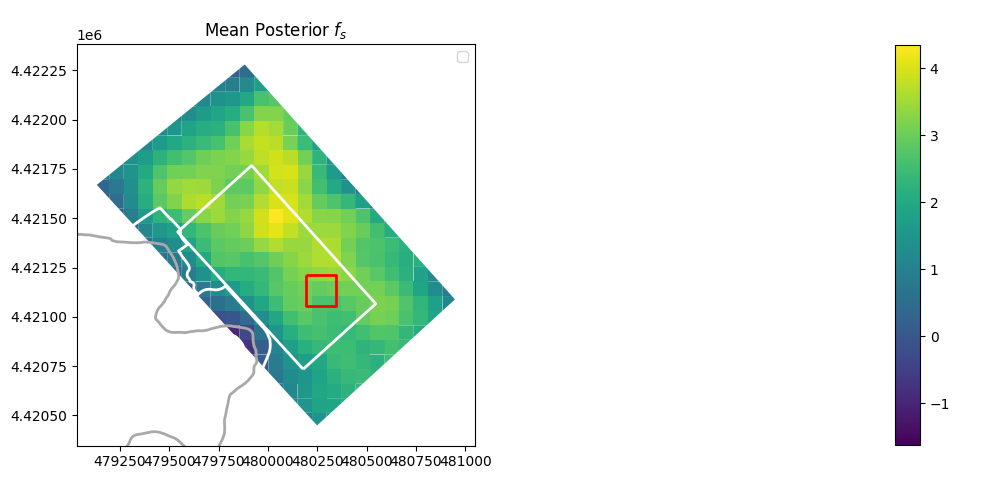

In [32]:
# Plot rectangular region within the box for fairmount_aoi_box, v1=(15, 10), v2=(20, 24)
v1 = (14, 14)
v2 = (16, 16)
v3 = (4, 17)
v4 = (6, 19)

# Get the box polygons from diagonal vertices for both hot and cold spots
coldspot_polygon = get_box_polygon_from_diag_vertices(park_name, v3, v4)
hotspot_polygon = get_box_polygon_from_diag_vertices(park_name, v1, v2)

# Plot both cold and hot spot polygons on the base map

#plot_polygon_on_basemap(coldspot_polygon, edgecolor='blue', facecolor='none', linewidth=2, label='Cold Spot', zorder=10)
plot_polygon_on_basemap(hotspot_polygon, edgecolor='red', facecolor='none', linewidth=2, label='Hot Spot', zorder=11)


In [33]:
cold_spot_event = get_daily_counts_in_box(park_points, coldspot_polygon)
hotspot_event = get_daily_counts_in_box(park_points, hotspot_polygon)

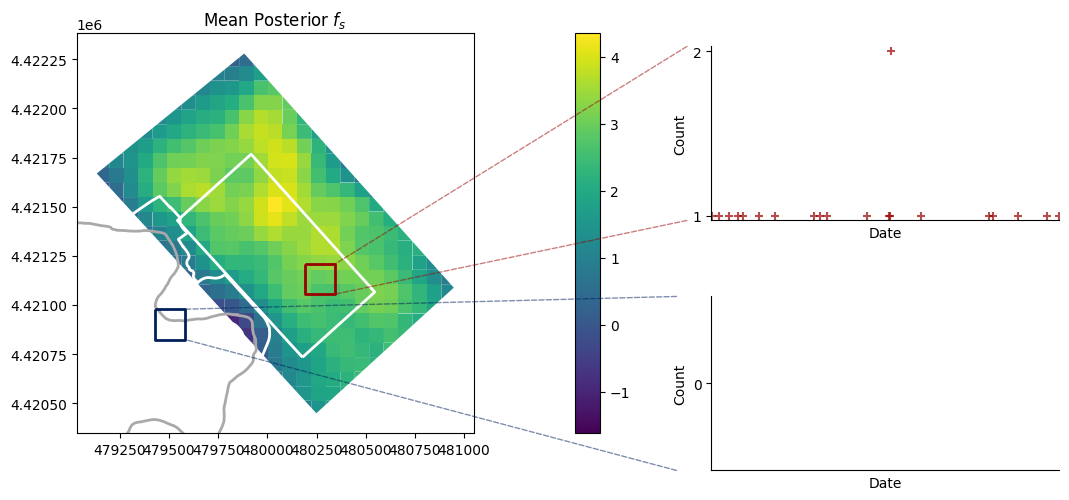

In [34]:
from matplotlib.patches import ConnectionPatch

# inset map
# parent axes ------------------------------------------------------------
model.plot_spatial(include_cov=False)

# Setup figure and axes
fig = plt.gcf()
axes = fig.get_axes()
fig.delaxes(axes[1])  # Remove right subplot
axes[0].set_position([0.1, 0.1, 1, 0.8])

# Get limits from left subplot
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

# Plot park boundaries on spatial axis
all_parks_gdf.plot(ax=axes[0], edgecolor='white', facecolor='none', linewidth=2)
philly_border.plot(ax=axes[0], edgecolor='darkgray', facecolor='none', linewidth=2)
coldspot_polygon.plot(ax=axes[0], edgecolor='#011f5b', facecolor='none', linewidth=2)
hotspot_polygon.plot(ax=axes[0], edgecolor='#990000', facecolor='none', linewidth=2)

# Set limits and add legend
axes[0].set_xlim(xlim)
axes[0].set_ylim(ylim)

# child axes ------------------------------------------------------------
# Place the inset axes outside axes[0], on the right (e.g., just outside axes[0]'s right edge)
# [left, bottom, width, height] in figure coordinates (e.g., [1.05, 0.2, 0.25, 0.25])

iax = fig.add_axes([1.01, 0, 0.4, 0.4], xticks=[], yticks=[], frameon=True)
plot_daily_counts(cold_spot_event, line_color='#011f5b', ax=iax)

# child axes for hot spot
iax_hotspot = fig.add_axes([1.01, 0.5, 0.4, 0.4], xticks=[], yticks=[], frameon=True)
plot_daily_counts(hotspot_event, line_color='#990000', ax=iax_hotspot)

# connect the two axes ------------------------------------------------------------
# Extract polygon coordinates
coords = list(coldspot_polygon.geometry.iloc[0].exterior.coords)

# Find right-top and right-bottom vertices
# Right means maximum x-coordinate
max_x = max(coord[0] for coord in coords)
right_vertices = [coord for coord in coords if coord[0] == max_x]

# Among right vertices, find top (max y) and bottom (min y)
right_top = max(right_vertices, key=lambda c: c[1])
right_bottom = min(right_vertices, key=lambda c: c[1])

# Get axis limits based on the position and size of iax itself (in display/axes coordinates)
bbox = iax.get_position()  # returns a Bbox in figure coordinates
xmin_fig, ymin_fig = bbox.x0, bbox.y0
xmax_fig, ymax_fig = bbox.x1, bbox.y1

# The fix is to use iax.transAxes for both ConnectionPatch instances:
con_top = ConnectionPatch(
    xyA=(-0.1, 1), coordsA=iax.transAxes,   # upper left of iax
    xyB=right_top, coordsB=axes[0].transData,
    arrowstyle='-',
    color='#011f5b',
    linewidth=1,
    linestyle='--',
    alpha=0.5
)
fig.add_artist(con_top)

con_bottom = ConnectionPatch(
    xyA=(-0.1, 0), coordsA=iax.transAxes,  # lower left of iax (axes coordinates), NOT transData
    xyB=right_bottom, coordsB=axes[0].transData,
    arrowstyle='-',
    color='#011f5b',
    linewidth=1,
    linestyle='--',
    alpha=0.5
)
fig.add_artist(con_bottom)

# connect the two axes ------------------------------------------------------------
# Extract polygon coordinates
coords = list(hotspot_polygon.geometry.iloc[0].exterior.coords)

# Find right-top and right-bottom vertices
# Right means maximum x-coordinate
max_x = max(coord[0] for coord in coords)
right_vertices = [coord for coord in coords if coord[0] == max_x]

# Among right vertices, find top (max y) and bottom (min y)
right_top = max(right_vertices, key=lambda c: c[1])
right_bottom = min(right_vertices, key=lambda c: c[1])

# Get axis limits based on the position and size of iax itself (in display/axes coordinates)
bbox = iax_hotspot.get_position()  # returns a Bbox in figure coordinates
xmin_fig, ymin_fig = bbox.x0, bbox.y0
xmax_fig, ymax_fig = bbox.x1, bbox.y1

# The fix is to use iax.transAxes for both ConnectionPatch instances:
con_top = ConnectionPatch(
    xyA=(-0.07, 1), coordsA=iax_hotspot.transAxes,   # upper left of iax
    xyB=right_top, coordsB=axes[0].transData,
    arrowstyle='-',
    color='#990000',
    linewidth=1,
    linestyle='--',
    alpha=0.5
)
fig.add_artist(con_top)

con_bottom = ConnectionPatch(
    xyA=(-0.07, 0), coordsA=iax_hotspot.transAxes,  # lower left of iax (axes coordinates), NOT transData
    xyB=right_bottom, coordsB=axes[0].transData,
    arrowstyle='-',
    color='#990000',
    linewidth=1,
    linestyle='--',
    alpha=0.5
)
fig.add_artist(con_bottom)



In [35]:
# Helper functions for spatial plotting
def plot_hotspots_with_halo(ax, hotspot_gdf, xlim, ylim, crs_26918=True):
    """Plot hotspots with halo effect on given axis."""
    # Filter geodataframe to only points within bounds
    if crs_26918:
        filtered_gdf = hotspot_gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
    else:
        # For OSM axis, already in 3857
        filtered_gdf = hotspot_gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
    
    # Extract x, y coordinates
    x = filtered_gdf.geometry.x
    y = filtered_gdf.geometry.y
    
    # Plot halo layers
    ax.plot(x, y, 'o', color='#FFC408', markersize=17, markeredgewidth=0, alpha=0.1)
    ax.plot(x, y, 'o', color='#FFC408', markersize=15, markeredgewidth=0, alpha=0.3)
    ax.plot(x, y, 'o', color='#FFC408', markersize=12, markeredgewidth=0, alpha=0.5)
    ax.plot(x, y, 'o', color='#F49719', markersize=9, markeredgewidth=0, alpha=0.7)
    
    # Plot main points
    ax.plot(x, y, 'o', color='#E86A2A', markersize=8, alpha=0.7)
    
    # Add final layer with white border
    if crs_26918:
        ax.plot(x, y, 'o', color='#D0104C', markersize=5, alpha=0.9,
                markeredgecolor='white', markeredgewidth=0.7)
    else:
        ax.plot(x, y, 'o', color='#D0104C', markersize=5, alpha=0.9)


def get_color_from_group_name(group_name):
    """Map group name to matplotlib color."""
    color = group_name.replace('json_', '').lower()
    valid_colors = {'red', 'blue', 'yellow', 'green', 'white', 'gray', 
                   'orange', 'purple', 'black', 'brown'}
    if color == "clear" or color not in valid_colors:
        return "gray"
    elif color == "white":
        return "#e7e6e6"  # use light gray for visibility
    else:
        return color


def plot_focus_group_points(ax, focus_group_gdfs, xlim, ylim, 
                            markersize=9, crs_26918=True):
    """Plot focus group points on given axis."""
    for group_name, gdf in focus_group_gdfs.items():
        color_mpl = get_color_from_group_name(group_name)
        
        if crs_26918:
            # Filter for spatial axis (26918)
            filtered = gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
            if not filtered.empty:
                ax.plot(filtered.geometry.x, filtered.geometry.y, 'o',
                       color=color_mpl, markersize=markersize,
                       markeredgewidth=1, markeredgecolor='white',
                       label=group_name)
        else:
            # For OSM axis (3857)
            if not gdf.empty:
                if gdf.crs != 'epsg:3857':
                    gdf_3857 = gdf.to_crs(epsg=3857)
                else:
                    gdf_3857 = gdf
                filtered_3857 = gdf_3857.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
                if not filtered_3857.empty:
                    ax.plot(filtered_3857.geometry.x, filtered_3857.geometry.y, 'o',
                           color=color_mpl, markersize=markersize,
                           markeredgewidth=1, markeredgecolor='white',
                           label=group_name)


def transform_to_3857(*gdfs):
    """Transform multiple GeoDataFrames to EPSG:3857."""
    return [gdf.to_crs(epsg=3857) for gdf in gdfs]


def plot_boundaries(ax, philly_2023_3857, all_parks_3857, osm_box):
    """Plot boundary layers on OSM axis."""
    philly_2023_3857.plot(ax=ax, edgecolor='#3f312b', facecolor='none',
                          linewidth=1, zorder=3, alpha=0.7)
    all_parks_3857.plot(ax=ax, color='none', edgecolor='#211E55',
                       linewidth=1.5, zorder=2, alpha=0.8)
    osm_box.plot(ax=ax, edgecolor='black', facecolor='none',
                linewidth=2, zorder=1)


def plot_land_use(ax, land_use_current, use_color):
    """Plot land use type on OSM axis."""
    land_use_current['type'] = land_use_current['type'].astype('category')
    cmap = ListedColormap(use_color)
    land_use_current[land_use_current['year'] == 2023].plot(
        ax=ax, column='type', cmap=cmap, alpha=0.8, legend=True,
        legend_kwds={'loc': 'center left', 'bbox_to_anchor': (1, 0.5),
                    'title': 'Land Use Type'}
    )


def setup_osm_axis(fig, position=[1, 0.1, 0.5, 0.8]):
    """Create and setup OSM axis."""
    osm_ax = fig.add_axes(position)
    osm_ax.set_title("OpenStreetMap View")
    osm_ax.set_axis_off()
    return osm_ax


def add_scalebar(osm_ax):
    """Add scale bar to OSM axis."""
    scalebar = ScaleBar(
        dx=1, units='m', dimension='si-length',
        length_fraction=0.25, location='lower right',
        scale_loc='bottom', box_color='white', box_alpha=0.8,
        border_pad=0.6, color='black',
        font_properties={'size': 10}
    )
    osm_ax.add_artist(scalebar)


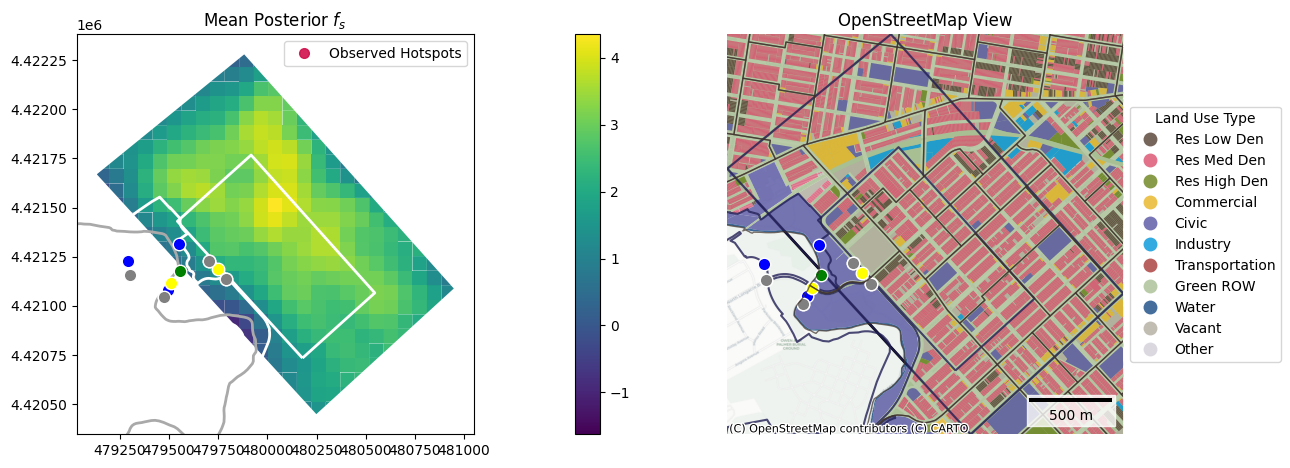

In [36]:
# Cleaner plotting code using helper functions
model.plot_spatial(include_cov=False)

# Setup figure and axes
fig = plt.gcf()
axes = fig.get_axes()
fig.delaxes(axes[1])  # Remove right subplot
axes[0].set_position([0.1, 0.1, 1, 0.8])

# Get limits from left subplot
xlim = axes[0].get_xlim()
ylim = axes[0].get_ylim()

# Plot park boundaries on spatial axis
all_parks_gdf.plot(ax=axes[0], edgecolor='white', facecolor='none', linewidth=2)
philly_border.plot(ax=axes[0], edgecolor='darkgray', facecolor='none', linewidth=2)

# Plot hotspots on spatial axis
plot_hotspots_with_halo(axes[0], dumping_hotspot_gdf, xlim, ylim, crs_26918=True)

# Plot focus group points on spatial axis
plot_focus_group_points(axes[0], focus_group_gdfs, xlim, ylim, markersize=9, crs_26918=True)

# Set limits and add legend
axes[0].set_xlim(xlim)
axes[0].set_ylim(ylim)
legend_handle = Line2D([0], [0], marker='o', linestyle='None', 
                      color='#D0104C', markerfacecolor='#D0104C',
                      markersize=7, alpha=0.9, label='Observed Hotspots')
axes[0].legend(handles=[legend_handle], loc='upper right')

# Setup OSM axis
osm_ax = setup_osm_axis(fig, position=[1, 0.1, 0.5, 0.8])

# Transform data to 3857 for OSM
osm_box, philly_2023_3857, all_parks_3857, land_use_3857 = transform_to_3857(
    all_boxes_gdf[all_boxes_gdf['PARKNAME'] == park_name],
    philly_2023,
    all_parks_gdf,
    land_use_current
)

# Plot boundaries and land use on OSM axis
plot_boundaries(osm_ax, philly_2023_3857, all_parks_3857, osm_box)
plot_land_use(osm_ax, land_use_3857, use_color)

# Plot hotspots on OSM axis (need to transform first)
filtered_gdf_26918 = dumping_hotspot_gdf.cx[xlim[0]:xlim[1], ylim[0]:ylim[1]]
filtered_gdf_3857 = filtered_gdf_26918.to_crs(epsg=3857)
osm_xlim = osm_box.total_bounds[[0, 2]]
osm_ylim = osm_box.total_bounds[[1, 3]]
plot_hotspots_with_halo(osm_ax, filtered_gdf_3857, osm_xlim, osm_ylim, crs_26918=False)

# Plot focus group points on OSM axis
plot_focus_group_points(osm_ax, focus_group_gdfs, osm_xlim, osm_ylim, markersize=9, crs_26918=False)

# Set OSM axis limits and add basemap
osm_ax.set_xlim(osm_xlim)
osm_ax.set_ylim(osm_ylim)
ctx.add_basemap(osm_ax, source=ctx.providers.CartoDB.Positron)

# Add scalebar
add_scalebar(osm_ax)

plt.show()


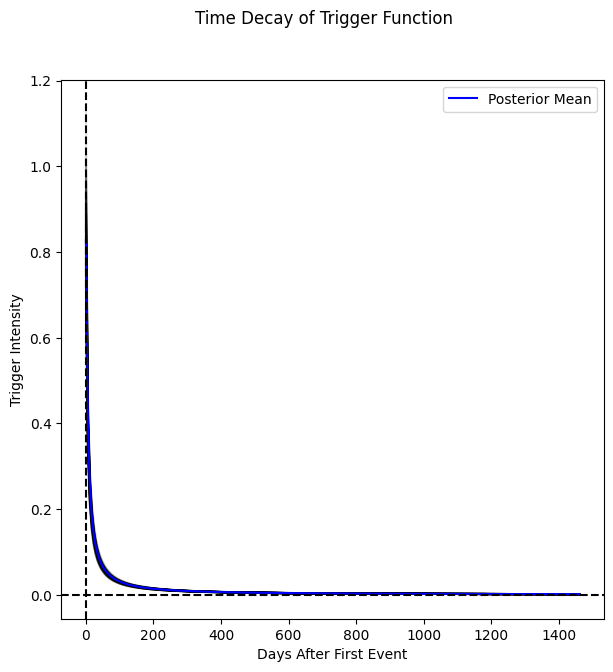

In [37]:
model.plot_trigger_time_decay()

/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_91435/1265717719.py:33: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


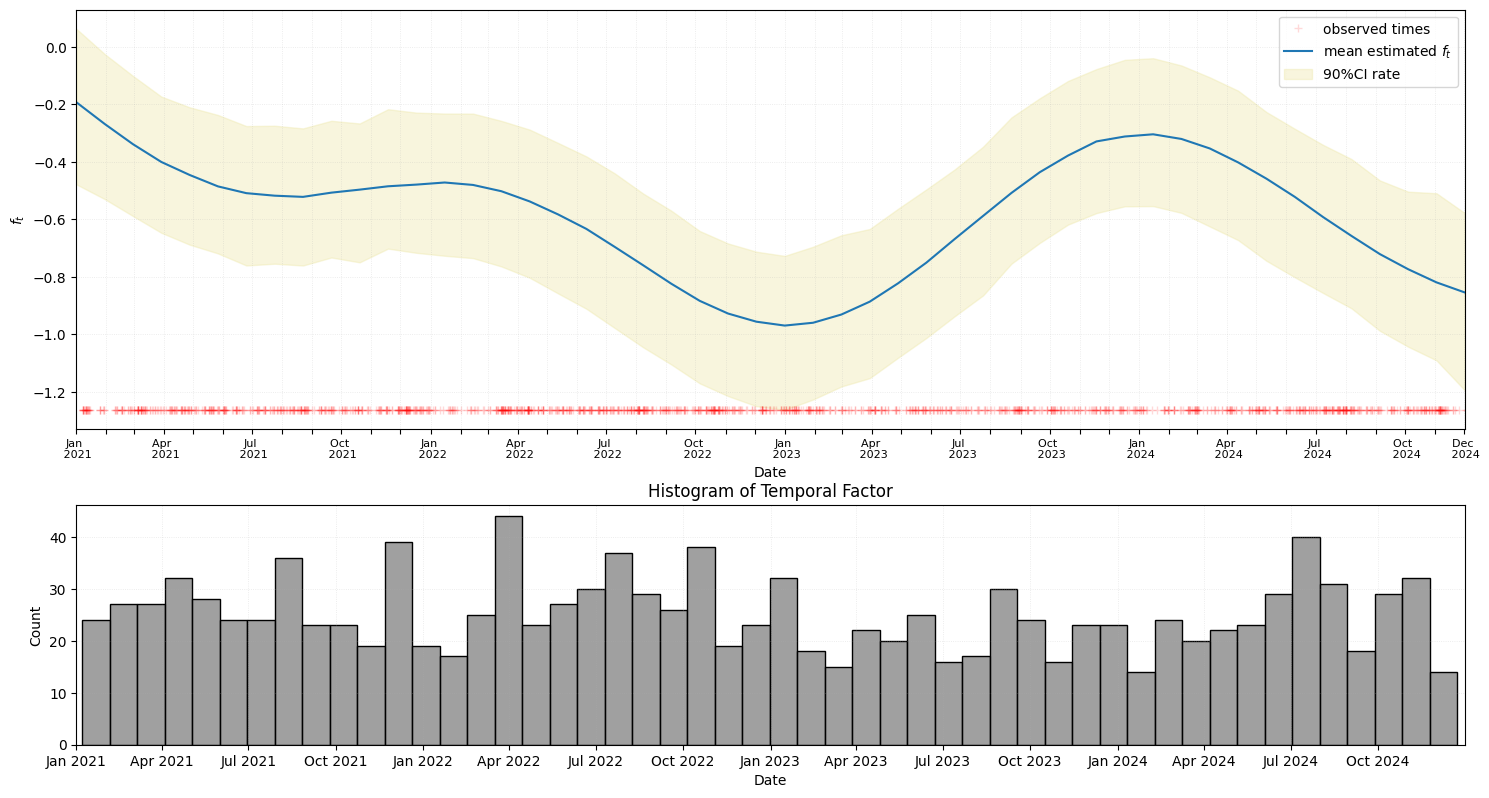

In [38]:
model.plot_temporal(start_date=min_time)

# Step 2: Grab the existing figure and axes
fig = plt.gcf()
axs = fig.get_axes()


# Plot histogram on ax2
main_ax = axs[0]
pos = main_ax.get_position()

hist_ax = fig.add_axes([pos.x0, -0.5, pos.width, 0.48])


sns.histplot(park_points['start_time'], bins=50, kde=False, ax=hist_ax, color='gray')
hist_ax.set_xlabel("Date")
hist_ax.set_ylabel("Count")
hist_ax.set_title("Histogram of Temporal Factor")
start = pd.to_datetime("2021-01-01") - pd.Timedelta(days=0)
end = pd.to_datetime("2024-12-31") + pd.Timedelta(days=0)
hist_ax.set_xlim(start, end)
hist_ax.margins(x=0)
hist_ax.grid(True, which='both', axis='both', linestyle=':', linewidth=0.6, alpha=0.3)

#hist_ax.xaxis.set_major_locator(plt.MaxNLocator(10))
hist_ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=3)
)
hist_ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

plt.tight_layout()
#plt.savefig('output/temp_mifflin_full.png', dpi=500, bbox_inches='tight')
plt.show()

/Users/yuxin/BSTPP/bstpp/main.py:1040: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/yuxin/BSTPP/bstpp/main.py:1040: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_91435/4024376285.py:44: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


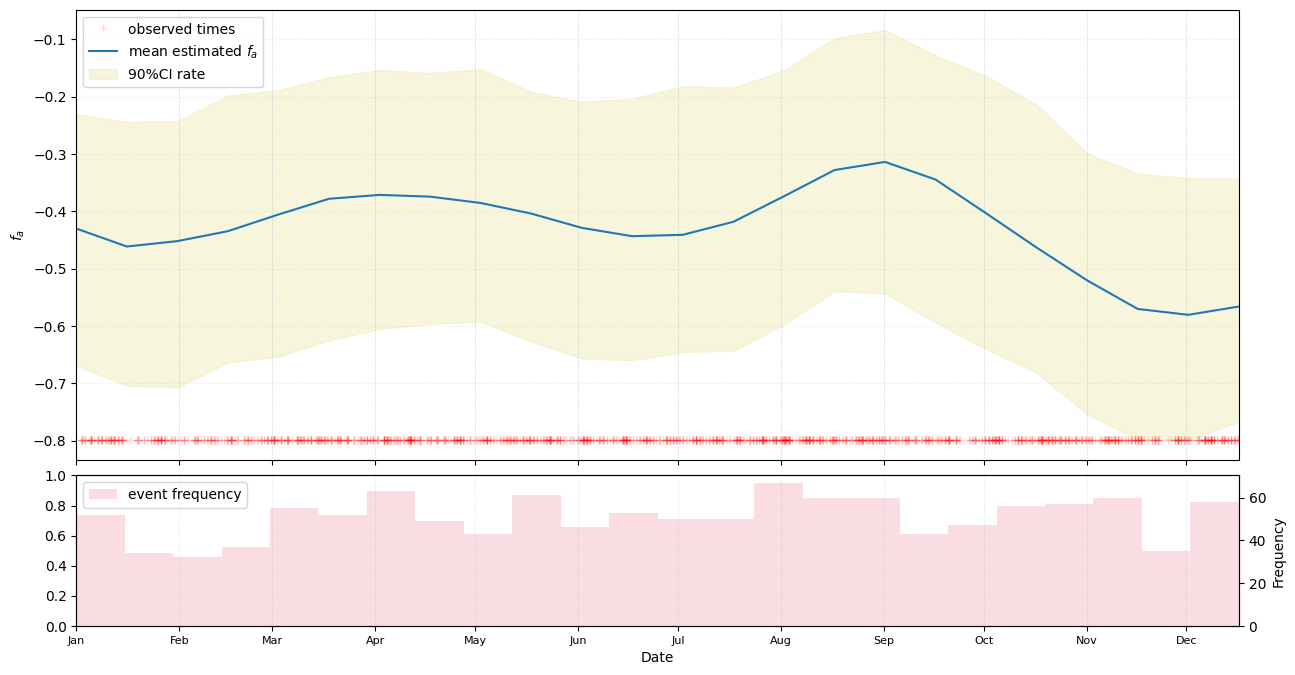

In [39]:
# Set up subplots (similar to temporal example)
fig, (ax_top, ax_bottom) = plt.subplots(
    2, 1,
    figsize=(15, 8),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05}
)

# Top: GP only
model.plot_seasonal_components(
    rescale=True,
    ref_year=2021,  # <-- change this to your reference year if needed
    show_gp=True,
    show_hist=False,
    ax=ax_top
)
ax_top.tick_params(labelbottom=False)
ax_top.set_xlabel("")

# Bottom: histogram only
model.plot_seasonal_components(
    rescale=True,
    ref_year=2021,  # <-- same reference year
    show_gp=False,
    show_hist=True,
    ax=ax_bottom
)

# Optional: add vertical month gridlines on BOTH panels for alignment
ref_year = 2021
offset = model.args['offset_seasonal']
month_days = np.cumsum([0] + [calendar.monthrange(ref_year, m)[1] for m in range(1, 12)])
month_days_offset = (month_days + offset) % model.S
sorted_idx = np.argsort(month_days_offset)
month_starts_labeled = month_days_offset[sorted_idx]

b_scale = model.args["n_s"] / model.S if True else 1.0  # adjust based on your rescale setting
x_a = np.arange(0, model.args["S"], model.args["S"]/model.args["n_s"]) / b_scale

for ax in (ax_top, ax_bottom):
    for x_pos in month_starts_labeled:
        ax.axvline(x_pos, linestyle=":", linewidth=0.6, alpha=0.25)

plt.tight_layout()
# plt.savefig(f'output_litteridx_emb/{park_name.split("_")[0]}_seasonal_trend.png', dpi=500, bbox_inches='tight')
plt.show()

## Other sanity checks

### Get the geometry from the grid coordinate


In [40]:
from bstpp.spatial_grid_helpers import get_grid_post_mean
from bstpp.spatial_grid_helpers import get_grid_post_mean, identify_hotspots_coldspots, plot_daily_event_counts

# Get grid results
result_gdf = get_grid_post_mean(model, include_cov=False)

In [41]:
result_gdf.head()

,grid_row,grid_col,post_mean,comp_grid_id,geometry
0,25,1,-0.016578,0,"POLYGON ((479122.352 4420439.669, 479195.765 4..."
1,25,2,-0.031186,1,"POLYGON ((479195.765 4420439.669, 479269.178 4..."
2,25,3,-0.248287,2,"POLYGON ((479269.178 4420439.669, 479342.591 4..."
3,25,4,-0.718363,3,"POLYGON ((479342.591 4420439.669, 479416.003 4..."
4,25,5,-1.395121,4,"POLYGON ((479416.003 4420439.669, 479489.416 4..."


Top 10 grids selected with post_mean range: 3.9053 to 4.3500
Buffered grids created with buffer distance based on 1/3 of grid dimensions


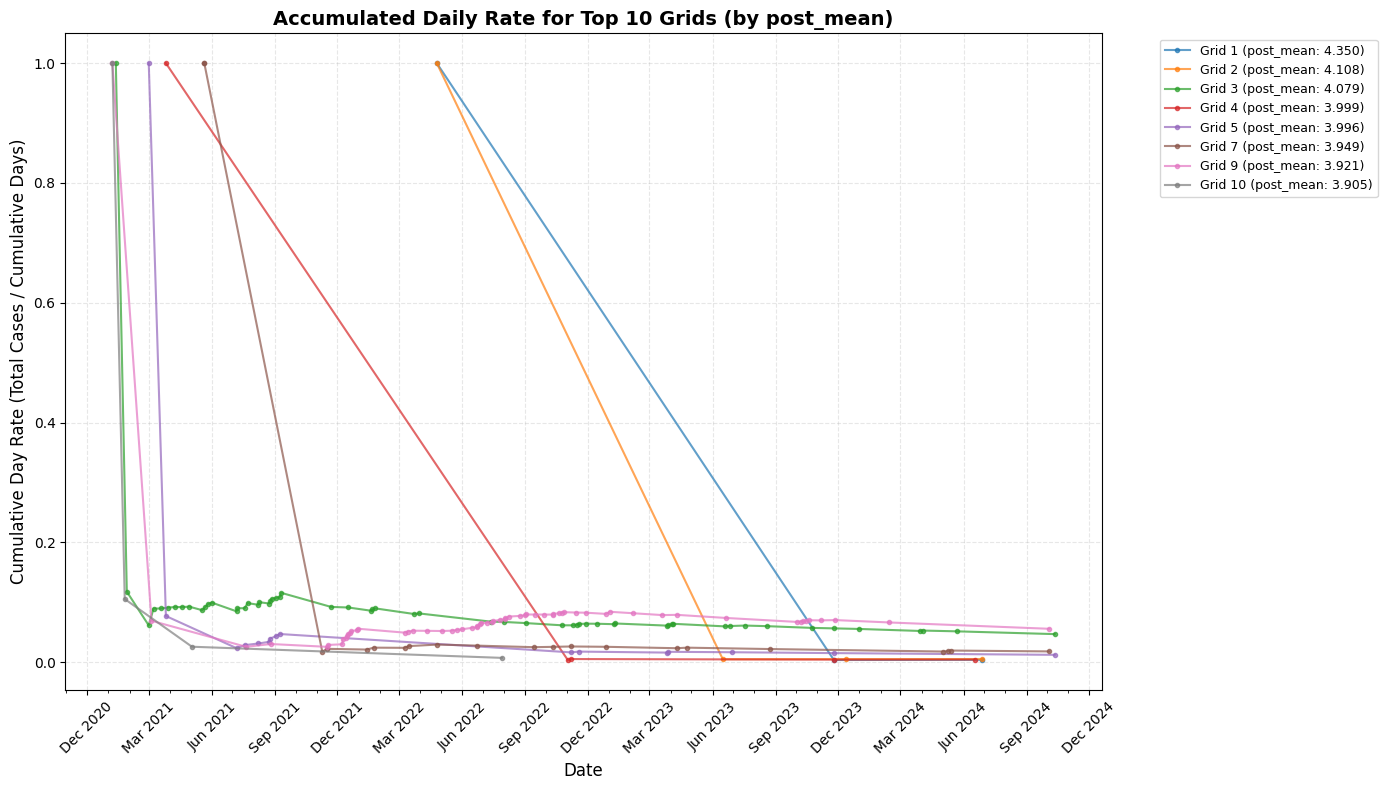


Summary Statistics:
Total events in top 10 grids: 194
Date range: 2021-01-07 00:00:00 to 2024-10-12 00:00:00
Total unique days with events: 142


In [42]:
# Get top 10 grids with highest post_mean
top_10_grids = result_gdf.nlargest(10, 'post_mean').copy()
top_10_grids['grid_id'] = range(1, 11)  # Add grid ID for identification

print(f"Top 10 grids selected with post_mean range: {top_10_grids['post_mean'].min():.4f} to {top_10_grids['post_mean'].max():.4f}")

# Create buffered grids: buffer each grid by 1/3 of its width or length
top_10_grids_buffered = top_10_grids.copy()

# Calculate buffer distance for each grid (1/3 of width or length, whichever is smaller)
for idx in top_10_grids_buffered.index:
    bounds = top_10_grids_buffered.loc[idx, 'geometry'].bounds
    width = bounds[2] - bounds[0]  # maxx - minx
    length = bounds[3] - bounds[1]  # maxy - miny
    buffer_distance = min(width, length) / 3.0
    top_10_grids_buffered.loc[idx, 'geometry'] = top_10_grids_buffered.loc[idx, 'geometry'].buffer(buffer_distance)

print(f"Buffered grids created with buffer distance based on 1/3 of grid dimensions")

# Prepare park_points for spatial join - drop any existing index_right column
park_points_clean = park_points.copy()
if 'index_right' in park_points_clean.columns:
    park_points_clean = park_points_clean.drop(columns=['index_right'])

# Spatial join: find events that intersect with each buffered grid
events_in_grids = park_points_clean.sjoin(top_10_grids_buffered, predicate='intersects', how='inner')

# Extract date from start_time (aggregate to day level)
events_in_grids['date'] = pd.to_datetime(events_in_grids['start_time']).dt.date

# Aggregate event counts by grid and date
daily_counts = events_in_grids.groupby(['grid_id', 'date']).size().reset_index(name='event_count')

# Convert date back to datetime for plotting
daily_counts['date'] = pd.to_datetime(daily_counts['date'])

# For each grid: calculate cumulative sum of cases and cumulative day rate
#  - Accumulated rate at each date = total cases up to date / total days since first case (including days with zero cases)

fig, ax = plt.subplots(figsize=(14, 8))

for grid_id in sorted(daily_counts['grid_id'].unique()):
    grid_data = daily_counts[daily_counts['grid_id'] == grid_id].sort_values('date').copy()
    # cumulative count
    grid_data['cumulative_event_count'] = grid_data['event_count'].cumsum()
    # total days since first case (calendar days, including those with zero events)
    first_date = grid_data['date'].min()
    grid_data['days_since_first'] = (grid_data['date'] - first_date).dt.days + 1
    # cumulative daily rate
    grid_data['cumulative_day_rate'] = grid_data['cumulative_event_count'] / grid_data['days_since_first']
    post_mean_val = top_10_grids[top_10_grids['grid_id'] == grid_id]['post_mean'].values[0]
    ax.plot(grid_data['date'], grid_data['cumulative_day_rate'],
            marker='o', markersize=3, linewidth=1.5, alpha=0.7,
            label=f'Grid {grid_id} (post_mean: {post_mean_val:.3f})')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Day Rate (Total Cases / Cumulative Days)', fontsize=12)
ax.set_title('Accumulated Daily Rate for Top 10 Grids (by post_mean)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Total events in top 10 grids: {len(events_in_grids)}")
print(f"Date range: {daily_counts['date'].min()} to {daily_counts['date'].max()}")
print(f"Total unique days with events: {daily_counts['date'].nunique()}")


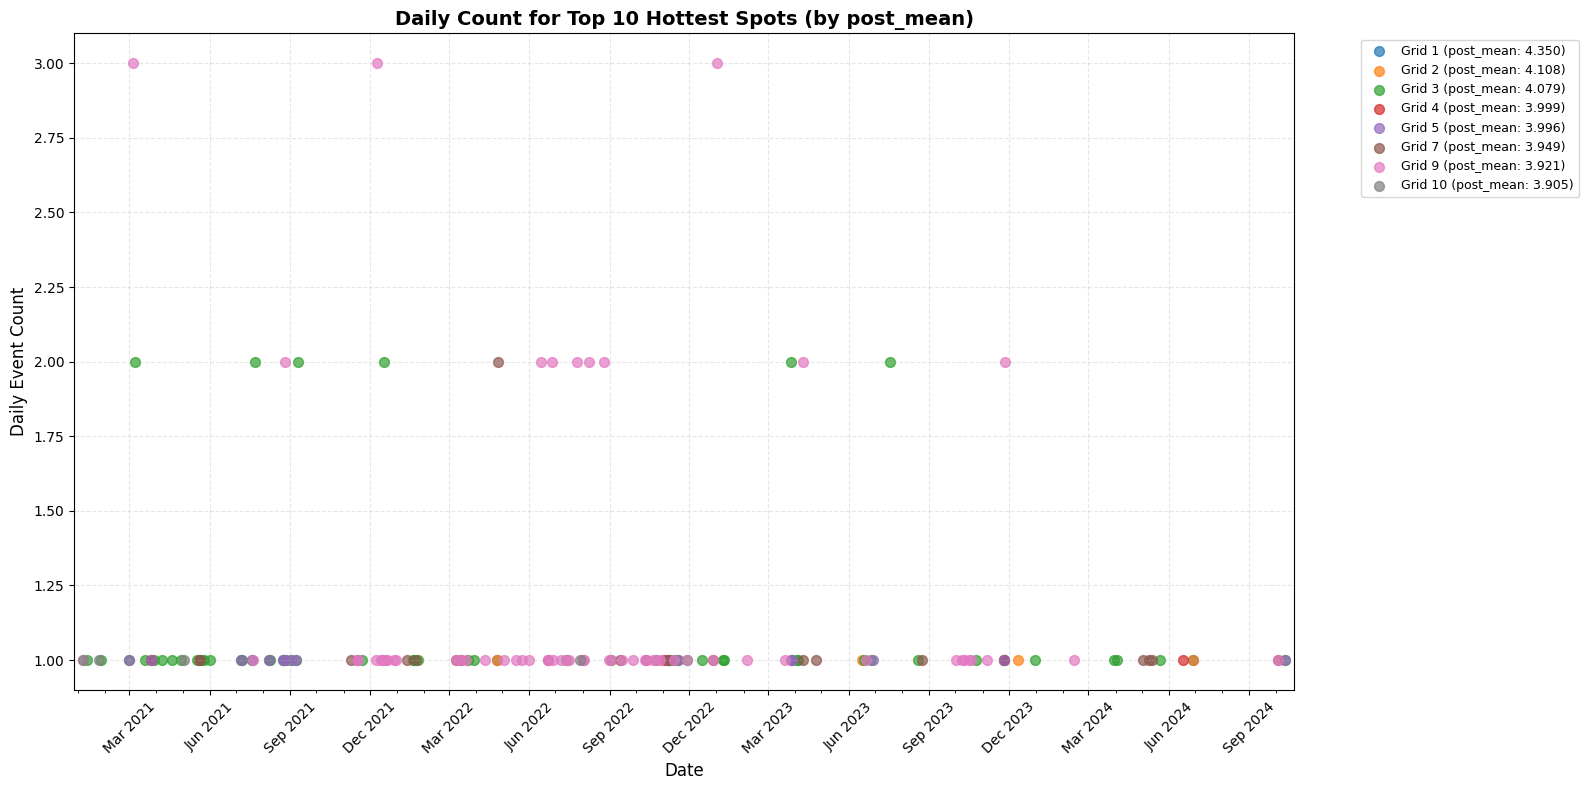


Summary Statistics for Daily Counts:
Total events in top 10 grids: 194
Date range: 2021-01-07 00:00:00 to 2024-10-12 00:00:00
Total unique days with events: 142
Max daily count in a single grid: 3
Average daily count per grid (on days with events): 1.12


In [43]:
# Plot daily counts (not cumulative) for top 10 hottest spots
# Reuse the top_10_grids and events_in_grids from Cell 37

# Get top 10 grids with highest post_mean (if not already defined)
if 'top_10_grids' not in locals():
    top_10_grids = result_gdf.nlargest(10, 'post_mean').copy()
    top_10_grids['grid_id'] = range(1, 11)
    
    # Create buffered grids
    top_10_grids_buffered = top_10_grids.copy()
    for idx in top_10_grids_buffered.index:
        bounds = top_10_grids_buffered.loc[idx, 'geometry'].bounds
        width = bounds[2] - bounds[0]
        length = bounds[3] - bounds[1]
        buffer_distance = min(width, length) / 3.0
        top_10_grids_buffered.loc[idx, 'geometry'] = top_10_grids_buffered.loc[idx, 'geometry'].buffer(buffer_distance)
    
    # Spatial join
    park_points_clean = park_points.copy()
    if 'index_right' in park_points_clean.columns:
        park_points_clean = park_points_clean.drop(columns=['index_right'])
    events_in_grids = park_points_clean.sjoin(top_10_grids_buffered, predicate='intersects', how='inner')

# Extract date from start_time (aggregate to day level)
events_in_grids['date'] = pd.to_datetime(events_in_grids['start_time']).dt.date

# Aggregate event counts by grid and date
daily_counts = events_in_grids.groupby(['grid_id', 'date']).size().reset_index(name='event_count')

# Convert date back to datetime for plotting
daily_counts['date'] = pd.to_datetime(daily_counts['date'])

# Get overall date range for axis limits
min_date = daily_counts['date'].min()
max_date = daily_counts['date'].max()

# Create plot - only show days with events (no lines, just markers)
fig, ax = plt.subplots(figsize=(16, 8))

# Color palette for 10 grids
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, grid_id in enumerate(sorted(daily_counts['grid_id'].unique())):
    grid_data = daily_counts[daily_counts['grid_id'] == grid_id].sort_values('date').copy()
    
    # Get post_mean for labeling
    post_mean_val = top_10_grids[top_10_grids['grid_id'] == grid_id]['post_mean'].values[0]
    
    # Plot daily counts - only days with events, no lines, just markers
    ax.scatter(
        grid_data['date'], 
        grid_data['event_count'],
        s=50,  # marker size
        alpha=0.7,
        color=colors[idx],
        label=f'Grid {grid_id} (post_mean: {post_mean_val:.3f})'
    )

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Event Count', fontsize=12)
ax.set_title('Daily Count for Top 10 Hottest Spots (by post_mean)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)

# Set x-axis limits to show full date range
ax.set_xlim(min_date - pd.Timedelta(days=10), max_date + pd.Timedelta(days=10))

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics for Daily Counts:")
print(f"Total events in top 10 grids: {len(events_in_grids)}")
print(f"Date range: {min_date} to {max_date}")
print(f"Total unique days with events: {daily_counts['date'].nunique()}")
print(f"Max daily count in a single grid: {daily_counts['event_count'].max()}")
print(f"Average daily count per grid (on days with events): {daily_counts['event_count'].mean():.2f}")


Bottom 10 grids selected with post_mean range: -4.3424 to -3.5431
Buffered cold-spot grids created with buffer distance based on 1/3 of grid dimensions


/var/folders/nr/q7sysy9j07x_5smd2gfx3j380000gn/T/ipykernel_91435/2430628222.py:67: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)


ValueError: Axis limits cannot be NaN or Inf

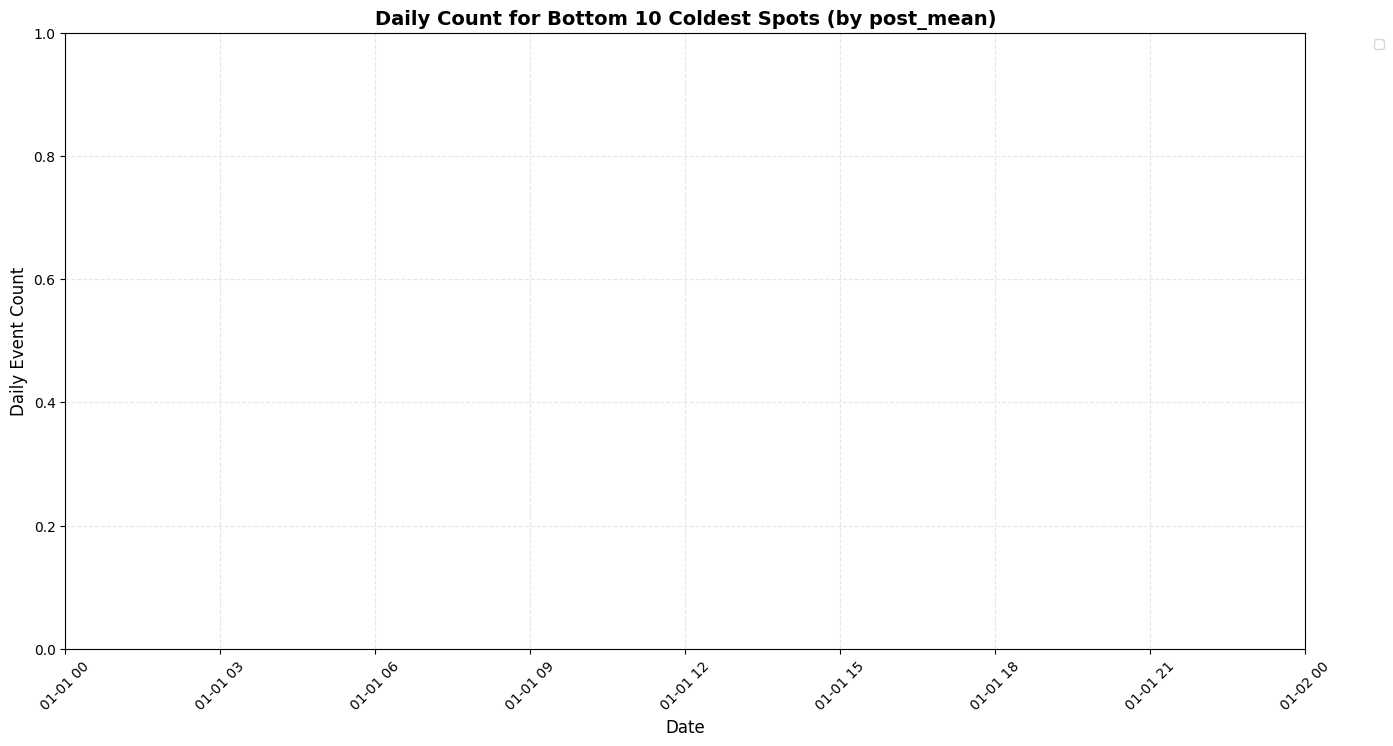

In [44]:
# Plot daily counts (not cumulative) for bottom 10 coldest spots

# Get bottom 10 grids with lowest post_mean (cold spots)
bottom_10_grids = result_gdf.nsmallest(10, 'post_mean').copy()
bottom_10_grids['grid_id'] = range(1, 11)  # Add grid ID for identification

print(f"Bottom 10 grids selected with post_mean range: {bottom_10_grids['post_mean'].min():.4f} to {bottom_10_grids['post_mean'].max():.4f}")

# Create buffered grids for cold spots: buffer each grid by 1/3 of its width or length
bottom_10_grids_buffered = bottom_10_grids.copy()

for idx in bottom_10_grids_buffered.index:
    bounds = bottom_10_grids_buffered.loc[idx, 'geometry'].bounds
    width = bounds[2] - bounds[0]  # maxx - minx
    length = bounds[3] - bounds[1]  # maxy - miny
    buffer_distance = min(width, length) / 3.0
    bottom_10_grids_buffered.loc[idx, 'geometry'] = bottom_10_grids_buffered.loc[idx, 'geometry'].buffer(buffer_distance)

print("Buffered cold-spot grids created with buffer distance based on 1/3 of grid dimensions")

# Prepare park_points for spatial join - drop any existing index_right column
park_points_clean_cold = park_points.copy()
if 'index_right' in park_points_clean_cold.columns:
    park_points_clean_cold = park_points_clean_cold.drop(columns=['index_right'])

# Spatial join: find events that intersect with each buffered cold-spot grid
events_in_cold_grids = park_points_clean_cold.sjoin(bottom_10_grids_buffered, predicate='intersects', how='inner')

# Extract date from start_time (aggregate to day level)
events_in_cold_grids['date'] = pd.to_datetime(events_in_cold_grids['start_time']).dt.date

# Aggregate event counts by grid and date
daily_counts_cold = events_in_cold_grids.groupby(['grid_id', 'date']).size().reset_index(name='event_count')

# Convert date back to datetime for plotting
daily_counts_cold['date'] = pd.to_datetime(daily_counts_cold['date'])

# Get overall date range for axis limits
min_date_cold = daily_counts_cold['date'].min()
max_date_cold = daily_counts_cold['date'].max()

# Create plot - only show days with events (no lines, just markers)
fig, ax = plt.subplots(figsize=(16, 8))

# Color palette for 10 grids
colors = plt.cm.tab10(np.linspace(0, 1, 10))

for idx, grid_id in enumerate(sorted(daily_counts_cold['grid_id'].unique())):
    grid_data = daily_counts_cold[daily_counts_cold['grid_id'] == grid_id].sort_values('date').copy()
    
    # Get post_mean for labeling
    post_mean_val = bottom_10_grids[bottom_10_grids['grid_id'] == grid_id]['post_mean'].values[0]
    
    # Plot daily counts - only days with events, no lines, just markers
    ax.scatter(
        grid_data['date'], 
        grid_data['event_count'],
        s=50,  # marker size
        alpha=0.7,
        color=colors[idx],
        label=f'Grid {grid_id} (post_mean: {post_mean_val:.3f})'
    )

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Daily Event Count', fontsize=12)
ax.set_title('Daily Count for Bottom 10 Coldest Spots (by post_mean)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)

# Set x-axis limits to show full date range
ax.set_xlim(min_date_cold - pd.Timedelta(days=10), max_date_cold + pd.Timedelta(days=10))

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics for Daily Counts (Cold Spots):")
print(f"Total events in bottom 10 grids: {len(events_in_cold_grids)}")
print(f"Date range: {min_date_cold} to {max_date_cold}")
print(f"Total unique days with events: {daily_counts_cold['date'].nunique()}")
print(f"Max daily count in a single grid: {daily_counts_cold['event_count'].max()}")
print(f"Average daily count per grid (on days with events): {daily_counts_cold['event_count'].mean():.2f}")


Bottom 10 grids selected with post_mean range: -2.0325 to -1.7296
Buffered cold-spot grids created with buffer distance based on 1/3 of grid dimensions


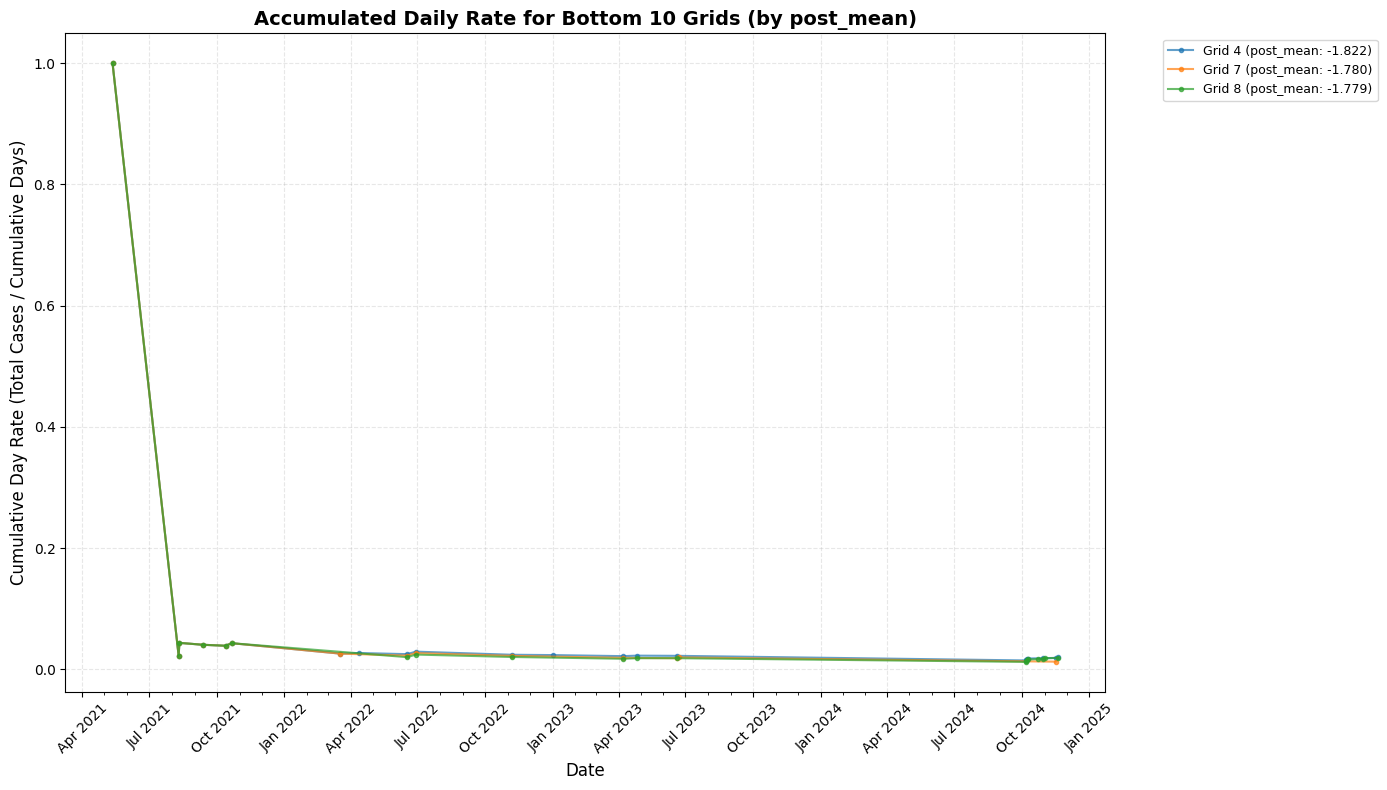


Summary Statistics for cold spots:
Total events in bottom 10 grids: 65
Date range: 2021-05-12 00:00:00 to 2024-11-19 00:00:00
Total unique days with events: 25


In [ ]:
# Get bottom 10 grids with lowest post_mean (cold spots)
bottom_10_grids = result_gdf.nsmallest(10, 'post_mean').copy()
bottom_10_grids['grid_id'] = range(1, 11)  # Add grid ID for identification

print(f"Bottom 10 grids selected with post_mean range: {bottom_10_grids['post_mean'].min():.4f} to {bottom_10_grids['post_mean'].max():.4f}")

# Create buffered grids for cold spots: buffer each grid by 1/3 of its width or length
bottom_10_grids_buffered = bottom_10_grids.copy()

for idx in bottom_10_grids_buffered.index:
    bounds = bottom_10_grids_buffered.loc[idx, 'geometry'].bounds
    width = bounds[2] - bounds[0]  # maxx - minx
    length = bounds[3] - bounds[1]  # maxy - miny
    buffer_distance = min(width, length) / 3.0
    bottom_10_grids_buffered.loc[idx, 'geometry'] = bottom_10_grids_buffered.loc[idx, 'geometry'].buffer(buffer_distance)

print("Buffered cold-spot grids created with buffer distance based on 1/3 of grid dimensions")

# Prepare park_points for spatial join - drop any existing index_right column
park_points_clean_cold = park_points.copy()
if 'index_right' in park_points_clean_cold.columns:
    park_points_clean_cold = park_points_clean_cold.drop(columns=['index_right'])

# Spatial join: find events that intersect with each buffered cold-spot grid
events_in_cold_grids = park_points_clean_cold.sjoin(bottom_10_grids_buffered, predicate='intersects', how='inner')

# Extract date from start_time (aggregate to day level)
events_in_cold_grids['date'] = pd.to_datetime(events_in_cold_grids['start_time']).dt.date

# Aggregate event counts by grid and date
daily_counts_cold = events_in_cold_grids.groupby(['grid_id', 'date']).size().reset_index(name='event_count')

# Convert date back to datetime for plotting
daily_counts_cold['date'] = pd.to_datetime(daily_counts_cold['date'])

# For each cold-spot grid: calculate cumulative sum of cases and cumulative day rate
#  - Accumulated rate at each date = total cases up to date / total days since first case (including days with zero cases)

fig, ax = plt.subplots(figsize=(14, 8))

for grid_id in sorted(daily_counts_cold['grid_id'].unique()):
    grid_data = daily_counts_cold[daily_counts_cold['grid_id'] == grid_id].sort_values('date').copy()
    # cumulative count
    grid_data['cumulative_event_count'] = grid_data['event_count'].cumsum()
    # total days since first case (calendar days, including those with zero events)
    first_date = grid_data['date'].min()
    grid_data['days_since_first'] = (grid_data['date'] - first_date).dt.days + 1
    # cumulative daily rate
    grid_data['cumulative_day_rate'] = grid_data['cumulative_event_count'] / grid_data['days_since_first']
    post_mean_val = bottom_10_grids[bottom_10_grids['grid_id'] == grid_id]['post_mean'].values[0]
    ax.plot(grid_data['date'], grid_data['cumulative_day_rate'],
            marker='o', markersize=3, linewidth=1.5, alpha=0.7,
            label=f'Grid {grid_id} (post_mean: {post_mean_val:.3f})')

ax.set_xlabel('Date', fontsize=12)
ax.set_ylabel('Cumulative Day Rate (Total Cases / Cumulative Days)', fontsize=12)
ax.set_title('Accumulated Daily Rate for Bottom 10 Grids (by post_mean)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3, linestyle='--')
ax.tick_params(axis='x', rotation=45)

# Format x-axis dates
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_minor_locator(mdates.MonthLocator())

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics for cold spots:")
print(f"Total events in bottom 10 grids: {len(events_in_cold_grids)}")
print(f"Date range: {daily_counts_cold['date'].min()} to {daily_counts_cold['date'].max()}")
print(f"Total unique days with events: {daily_counts_cold['date'].nunique()}")

